In [1]:
from networkx.convert import to_networkx_graph
from torch_geometric.utils import to_networkx


import os
from pathlib import Path

%load_ext autoreload
%autoreload 2

PROJECT_DIR = Path.cwd().parent
os.chdir(PROJECT_DIR)

print("PROJECT_DIR:", PROJECT_DIR)
print("Current directory:", Path.cwd())

import numpy as np


from matplotlib import pyplot as plt

from experiments import (
    experiment_train,
    experiment_local_attack_direct,
    experiment_global_attack_direct
)
import helpers.selector_pipeline_helpers

from sparse_smoothing.utils import load_and_standardize
from sparse_smoothing.models import GCN

files = ["cache/demo.json", "cache/demo/demo_1.pt", "cache/evasion_global_adj.json", "cache/evasion_global_attr.json", "cache/evasion_global_adj/evasion_global_adj_1.pt", "cache/evasion_global_attr/evasion_global_attr_1.pt"]

for file_path in files:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"{file_path} has been deleted.")
    else:
        print(f"{file_path} does not exist.")

%matplotlib inline




PROJECT_DIR: E:\Masterarbeit\AttackerGNN
Current directory: E:\Masterarbeit\AttackerGNN


Use from seml.experiment import setup_logger instead.
Note that seml.experiment.Experiment already includes the logger setup.
See https://github.com/TUM-DAML/seml/blob/master/examples/example_experiment.py


[08/16/26 20:49:18] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=218611;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=893627;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

[08/16/26 20:49:18] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=543812;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=66326;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

cache/demo.json does not exist.
cache/demo/demo_1.pt does not exist.
cache/evasion_global_adj.json does not exist.
cache/evasion_global_attr.json does not exist.
cache/evasion_global_adj/evasion_global_adj_1.pt does not exist.
cache/evasion_global_attr/evasion_global_attr_1.pt does not exist.


In [2]:
# ── Dataset / split ─────────────────────────────────────────────────────────
DATASET = 'cora_ml'
SAMPLING = 'stratified'
SPLIT = 'ratio'

# All experiments in this notebook are repeated for these seeds.
# Add/remove values here; every raw table keeps `seed`, while displayed tables
# and plots aggregate over this list.
SEEDS = [0,1]
if not SEEDS:
    raise ValueError("SEEDS must contain at least one integer seed.")
SEEDS = [int(seed) for seed in SEEDS]
SEED = SEEDS[0]  # compatibility alias; never use this for an experiment loop
N_SEEDS = len(SEEDS)

TRAIN_RATIO = 0.15
VAL_RATIO = 0.10
TEST_RATIO = 0.30

# ── Victim model ─────────────────────────────────────────────────────────────
MODEL_NAME = 'GCN'
MODEL_LABEL = 'GCN'
TRAIN_EPOCHS = 200
HIDDEN = 64
INDUCTIVE = True
DROPOUT_VICTIM = 0.5
LR_VICTIM = 1e-2
WEIGHT_DECAY_VICTIM = 1e-3
PATIENCE_VICTIM = 300
MAX_EPOCHS_VICTIM = 3000

# ── V4 mining params ─────────────────────────────────────────────────────────
USE_PRBCD_CANDIDATES = True
N_PRBCD_RUNS = 1
MINER = 'prbcd'
MINER_LOCAL_FACTOR = 0.5
DEGREE_CAP_PCT = None
PRBCD_BUDGET_FRACTION = 0.5
CANDIDATE_SET_SIZES = [1000, 2000]
PRBCD_CANDIDATE_FRACTIONS = [0.0]
SCORING_MODES = ["endpoint","subset_accuracy_drop"]
LABEL_MODES = ["continuous"]
EXTREME_FRACTIONS = [0.3]
PRBCD_EPOCHS = 5
PRBCD_SEARCH_SPACE = 200_000
PRBCD_N_EPOCHS_RESAMPLING = 1

# ── Logging ─────────────────────────────────────────────────────────

RQ2_OUT_DIR = Path("extendedPlotting/final_runs/RQ2")
RQ2_OUT_DIR.mkdir(parents=True, exist_ok=True)

RQ3_OUT_DIR = Path("extendedPlotting/final_runs/RQ3")
RQ3_OUT_DIR.mkdir(parents=True, exist_ok=True)


# ── RQ3 subgraph-selector sweep ─────────────────────────────────────────────
# Every requested combination is constructed and trained. Only §8 consumes
# the complete Cartesian product. Legacy RQ3 diagnostics use the primary
# combination selected below.
# A value of 1.0 is an explicit whole-graph selector condition. It uses all
# graph nodes/edges for message passing, while candidate labels are still
# obtained from a finite sampled candidate set.
RQ3_SUBGRAPH_FRACTIONS = [1.0]
RQ3_SUBGRAPH_TRAINING_CANDIDATE_SIZES = [2500,5000,10000]
RQ3_SUBGRAPH_SEEDS = [20]
RQ3_SUBGRAPH_SCORING_MODES = ["endpoint","subset_accuracy_drop"]
RQ3_SUBGRAPH_METHODS = ["stratified_context", "forest_fire"]

# One combination exposed through the legacy names `mining_runs`,
# `lp_training_runs`, and `LP_MODEL_VARIANTS`. This prevents all experiments
# except §8 from silently expanding over the new sweep dimensions.
RQ3_PRIMARY_SUBGRAPH_FRACTION = 1.0
RQ3_PRIMARY_TRAINING_CANDIDATE_SIZE = 10000
RQ3_PRIMARY_SUBGRAPH_SEED = 20
RQ3_PRIMARY_SUBGRAPH_METHOD = "stratified_context"

# ── V4 subset-scoring params ─────────────────────────────────────────────────
N_SUBSETS = 1000
SUBSET_FRACTION = 0.05

# The helper owns the exact schema identifiers. The notebook imports them in
# the mining cell and writes them into every cache key and run dictionary.
# Canonical raw target:
#   mean harmful accuracy drop of subsets in which an edge was selected.

# ── Scorer training params ───────────────────────────────────────────────────
SCORER_HIDDEN = 64
SCORER_EPOCHS = 200
SCORER_LR = 0.01
VAL_FRACTION = 0.2
PATIENCE = 20
# Continuous subset scores are not class-balanced. Keep None unless deliberately
# running a separate projected-label ablation later.
BALANCE_RATIO = None

# ── Reproducibility / aggregation helpers ────────────────────────────────────
import os
import random
import pandas as pd
import torch

from pathlib import Path
from datetime import datetime


def set_global_seed(seed: int, deterministic: bool = True) -> None:
    """Seed Python, NumPy and PyTorch before every independent run."""
    seed = int(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def aggregate_over_seeds(
    frame: pd.DataFrame,
    group_cols: list[str],
    metric_cols: list[str] | None = None,
) -> pd.DataFrame:
    """Return mean/std/SEM and number of distinct seeds for numeric metrics."""
    if frame is None or frame.empty:
        return pd.DataFrame()
    missing = [column for column in group_cols if column not in frame.columns]
    if missing:
        raise KeyError(f"Missing grouping columns: {missing}")
    if "seed" not in frame.columns:
        raise KeyError("Every raw experiment table must contain a 'seed' column.")
    if metric_cols is None:
        metric_cols = [
            column for column in frame.select_dtypes(include=[np.number]).columns
            if column not in set(group_cols) | {"seed"}
        ]
    metric_cols = [column for column in metric_cols if column in frame.columns]

    if not group_cols:
        row = {"n_seeds": int(frame["seed"].nunique())}
        for metric in metric_cols:
            values = pd.to_numeric(frame[metric], errors="coerce")
            count = int(values.notna().sum())
            mean = float(values.mean()) if count else np.nan
            std = float(values.std(ddof=1)) if count > 1 else 0.0
            row[f"{metric}_mean"] = mean
            row[f"{metric}_std"] = std
            row[f"{metric}_count"] = count
            row[f"{metric}_sem"] = std / np.sqrt(max(1, count))
        return pd.DataFrame([row])

    grouped = frame.groupby(group_cols, dropna=False)
    pieces = []
    if metric_cols:
        stats = grouped[metric_cols].agg(["mean", "std", "count"])
        stats.columns = [f"{metric}_{stat}" for metric, stat in stats.columns]
        stats = stats.reset_index()
        for metric in metric_cols:
            std_col = f"{metric}_std"
            count_col = f"{metric}_count"
            if std_col in stats:
                stats[std_col] = stats[std_col].fillna(0.0)
                stats[f"{metric}_sem"] = stats[std_col] / np.sqrt(
                    stats[count_col].clip(lower=1)
                )
        pieces.append(stats)
    seed_counts = grouped["seed"].nunique().rename("n_seeds").reset_index()
    if not pieces:
        return seed_counts
    return pieces[0].merge(seed_counts, on=group_cols, how="left")


def add_mean_std_band(ax, x, mean, std, *, label=None, **plot_kwargs):
    """Plot a seed mean and a ±1 standard-deviation band."""
    x = np.asarray(x)
    mean = np.asarray(mean, dtype=float)
    std = np.nan_to_num(np.asarray(std, dtype=float), nan=0.0)
    line = ax.plot(x, mean, label=label, **plot_kwargs)[0]
    ax.fill_between(x, mean - std, mean + std, alpha=0.18, color=line.get_color())
    return line

set_global_seed(SEED)
print(f"Configured {N_SEEDS} seeds: {SEEDS}")


Configured 2 seeds: [0, 1]


Training victim model for seed=0


[08/16/26 20:49:23] INFO     {'dataset': 'cora_ml', 'model_params': {'label': 'GCN',        ]8;id=271493;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=536110;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#180\180]8;;\
                             'model': 'GCN', 'do_cache_adj_prep': True, 'n_filters': 64,                           
                             'dropout': 0.5, 'svd_params': None, 'jaccard_params': None,                           
                             'gdc_params': {'alpha': 0.15, 'k': 64}}, 'train_params':                              
                             {'lr': 0.01, 'weight_decay': 0.001, 'patience': 300,                                  
                             'max_epochs': 3000}, 'binary_attr': False, 'make_undirected':                         
                             True, 'seed': 0, 'artifact_dir': 'cache',                                             
                             'model_storage_type': 'demo_custom_split', 'ppr_cache_params':                        
                             {}, 'device': 'cpu', 'display_steps': 100, 'data_device':                             
                             'cpu'}                                                                                

                    INFO     Training set size: 140                                         ]8;id=318046;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=499748;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#216\216]8;;\

                    INFO     Validation set size: 140                                       ]8;id=529202;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=146039;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#217\217]8;;\

                    INFO     Test set size: 2530                                            ]8;id=838234;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=262674;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#218\218]8;;\

...

[08/16/26 20:50:15] INFO                                                                                ]8;id=739595;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=231169;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  800: loss_train: 0.07845, loss_val: 0.55637, acc_train: 1.00000,               
                             acc_val: 0.82857                                                                      

[08/16/26 20:50:19] INFO                                                                                ]8;id=446830;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=855546;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  900: loss_train: 0.07878, loss_val: 0.59411, acc_train: 1.00000,               
                             acc_val: 0.80714                                                                      

[08/16/26 20:50:20] INFO     Test accuracy is 0.8324110507965088 with seed 1                ]8;id=896870;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=731560;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#271\271]8;;\

                    INFO     Lock 3065561293008 acquired on cache\demo_custom_split.json.lock       ]8;id=665013;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=954220;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 3065561293008 released on cache\demo_custom_split.json.lock       ]8;id=77591;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=27993;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

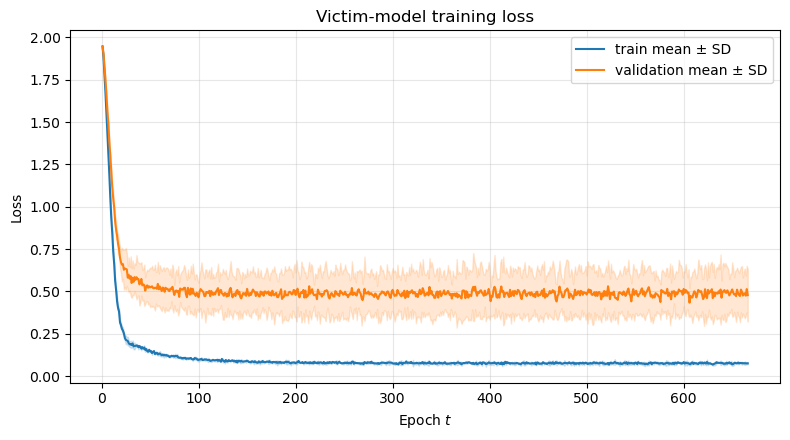

Victim accuracy over 2 seeds: 83.38% ± 0.20% SD


,n_seeds,clean_accuracy_mean,clean_accuracy_std,clean_accuracy_count,clean_accuracy_sem,n_train_epochs_mean,n_train_epochs_std,n_train_epochs_count,n_train_epochs_sem,n_val_epochs_mean,n_val_epochs_std,n_val_epochs_count,n_val_epochs_sem
0,2,0.833794,0.001956,2,0.001383,786.0,169.705627,2,120.0,786.0,169.705627,2,120.0


In [3]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

seed_victim_runs = []
train_curve_rows = []
train_summary_rows = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for seed in SEEDS:
    print(f"Training victim model for seed={seed}")

    stats = experiment_train.run(
        data_dir='./data',
        dataset=DATASET,
        model_params=dict(
            label=MODEL_LABEL,
            model=MODEL_NAME,
            do_cache_adj_prep=True,
            n_filters=64,
            dropout=DROPOUT_VICTIM,
            svd_params=None,
            jaccard_params=None,
            gdc_params={"alpha": 0.15, "k": 64},
        ),
        train_params=dict(
            lr=LR_VICTIM,
            weight_decay=WEIGHT_DECAY_VICTIM,
            patience=PATIENCE_VICTIM,
            max_epochs=MAX_EPOCHS_VICTIM,
        ),
        binary_attr=False,
        make_undirected=True,
        seed=seed,
        artifact_dir='cache',
        model_storage_type='demo_custom_split',
        ppr_cache_params=dict(),
        device="cpu",
        data_device="cpu",
        display_steps=100,
        debug_level="info",
        custom_split_ratios=None,
    )

    model_seed = stats["model"]
    graph_seed = stats["graph"]
    idx_train_seed = stats["idx_train"]
    idx_val_seed = stats["idx_val"]
    idx_test_seed = stats["idx_test"]
    model_seed.eval()

    attr_matrix_seed, adj_matrix_seed, labels_raw_seed = graph_seed[:3]
    model_device = next(model_seed.parameters()).device
    row, col, value = adj_matrix_seed.coo()
    edge_index_seed = torch.stack([row, col], dim=0).long().to(model_device)
    edge_weight_seed = (
        torch.ones(edge_index_seed.size(1), dtype=torch.float32, device=model_device)
        if value is None else value.float().to(model_device)
    )
    attr_seed = attr_matrix_seed.float().to(model_device)
    labels_seed = labels_raw_seed.long().to(model_device)
    n_nodes_seed = int(adj_matrix_seed.sizes()[0])
    n_edges_directed_seed = int(adj_matrix_seed.nnz())
    n_undirected_seed = n_edges_directed_seed // 2
    n_edges_possible_seed = n_nodes_seed * (n_nodes_seed - 1) // 2
    clean_acc_seed = float(stats["accuracy"])

    context = {
        "seed": int(seed),
        "dataset": DATASET,
        "train_statistics": stats,
        "clean_acc": clean_acc_seed,
        "model": model_seed,
        "graph": graph_seed,
        "idx_train": idx_train_seed,
        "idx_val": idx_val_seed,
        "idx_test": idx_test_seed,
        "device": model_device,
        "n_nodes": n_nodes_seed,
        "n_edges_directed": n_edges_directed_seed,
        "n_edges_undirected": n_undirected_seed,
        "n_edges_possible": n_edges_possible_seed,
        "attr_matrix": attr_matrix_seed,
        "adj_matrix": adj_matrix_seed,
        "labels_raw": labels_raw_seed,
        "edge_index": edge_index_seed,
        "edge_weight": edge_weight_seed,
        "attr": attr_seed,
        "labels": labels_seed,
    }
    seed_victim_runs.append(context)

    for split, values in (
        ("train", stats.get("trace_train", [])),
        ("validation", stats.get("trace_val", [])),
    ):
        for epoch, loss in enumerate(values, start=1):
            train_curve_rows.append({
                "seed": int(seed),
                "split": split,
                "epoch": int(epoch),
                "loss": float(loss),
            })

    train_summary_rows.append({
        "seed": int(seed),
        "clean_accuracy": clean_acc_seed,
        "n_train_epochs": len(stats.get("trace_train", [])),
        "n_val_epochs": len(stats.get("trace_val", [])),
    })

SEED_CONTEXTS = seed_victim_runs

train_curve_df = pd.DataFrame(train_curve_rows)
train_summary_raw_df = pd.DataFrame(train_summary_rows)
train_summary_df = aggregate_over_seeds(
    train_summary_raw_df,
    group_cols=[],
    metric_cols=["clean_accuracy", "n_train_epochs", "n_val_epochs"],
)

curve_summary = (
    train_curve_df.groupby(["split", "epoch"], as_index=False)
    .agg(loss_mean=("loss", "mean"), loss_std=("loss", "std"), n_seeds=("seed", "nunique"))
)
curve_summary["loss_std"] = curve_summary["loss_std"].fillna(0.0)
curve_summary = curve_summary[curve_summary["n_seeds"] == N_SEEDS].copy()
if curve_summary.empty:
    raise RuntimeError("No victim-training epochs are shared by every configured seed.")

fig, ax = plt.subplots(figsize=(8, 4.5))
for split, group in curve_summary.groupby("split", sort=False):
    group = group.sort_values("epoch")
    add_mean_std_band(
        ax,
        group["epoch"],
        group["loss_mean"],
        group["loss_std"],
        label=f"{split} mean ± SD",
    )
ax.set_xlabel('Epoch $t$')
ax.set_ylabel("Loss")
ax.set_title("Victim-model training loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

clean_mean = train_summary_raw_df["clean_accuracy"].mean()
clean_std = train_summary_raw_df["clean_accuracy"].std(ddof=1) if N_SEEDS > 1 else 0.0
print(f"Victim accuracy over {N_SEEDS} seeds: {100*clean_mean:.2f}% ± {100*clean_std:.2f}% SD")
display(train_summary_df)


# RQ2 — Mining and Evaluating Harmful Edge Perturbations

RQ1 showed that the scalability of PR-BCD depends on restricting optimization to a sampled candidate block. RQ2 therefore studies whether victim-model evaluations can produce a useful harmfulness ranking over candidate edge flips.

For `subset_accuracy_drop`, one random subset of candidate flips is applied at a time. Let \(d_t=A(G)-A(G\oplus S_t)\) be the signed evaluation-accuracy drop of subset \(S_t\). For candidate edge \(e_i\), the canonical mined target is

\[
s_i
=
\frac{\sum_{t:e_i\in S_t}\max(0,d_t)}
     {\sum_t \mathbf{1}[e_i\in S_t]}.
\]

Thus, \(s_i\) is the **mean harmful subset drop observed when edge \(e_i\) was selected**. It corrects for unequal inclusion frequency.

This is an edge-associated subset score, not an isolated causal effect. Interactions, redundancy, and cancellation between jointly flipped edges remain part of the signal. The later oracle and PR-BCD experiments test whether the resulting noisy score nevertheless provides a useful ranking.

Every mining run stores:

- signed and harmful subset drops;
- inclusion counts;
- raw mean harmful scores;
- normalized scores in \([0,1]\);
- within-run percentile ranks;
- an explicit schema version and score definition.


In [4]:
from helpers.selector_pipeline_helpers import _edge_set
from IPython.display import display
import random
import pandas as pd

# Generated by ChatGPT 5.1
def _safe_config_value(value):
    text = f"{value:.12g}" if isinstance(value, float) else str(value)
    return (
        text.strip()
        .replace(" ", "")
        .replace("/", "-")
        .replace("\\", "-")
        .replace(".", "p")
        .replace("+", "")
        .replace("-", "m")
    )

def sample_random_candidates(num_nodes: int, count: int, *, seed: int,):
    """Sample candidate edges"""
    rng = random.Random(int(seed))
    sampled = set()
    while len(sampled) < count:
        u = rng.randrange(num_nodes)
        v = rng.randrange(num_nodes)
        if u == v:
            continue
        sampled.add((min(u, v), max(u, v)))
    return sampled

# ---------------------------------------------------------
# Build random candidate sets
# ---------------------------------------------------------

candidate_runs = []

for context in SEED_CONTEXTS:
    seed = int(context["seed"])
    n_nodes = int(context["n_nodes"])
    edge_index = context["edge_index"]
    orig_edges = _edge_set(edge_index)
    for candidate_set_size in CANDIDATE_SET_SIZES:
        candidate_seed = (seed + 20 * candidate_set_size + 17)
        random_candidates = sample_random_candidates(
            num_nodes=n_nodes,
            count=candidate_set_size,
            seed=candidate_seed,
        )
        candidates_for_config = list(random_candidates)
        random.Random(candidate_seed + 1).shuffle(candidates_for_config)
        n_delete_candidates = sum(edge in orig_edges for edge in candidates_for_config)
        n_add_candidates = (candidate_set_size - n_delete_candidates)
        candidate_runs.append({
            "seed": seed,
            "context": context,
            "candidate_set_size": candidate_set_size,
            "n_add_candidates": n_add_candidates,
            "n_delete_candidates": n_delete_candidates,
            "candidates": candidates_for_config,
        })

# ---------------------------------------------------------
# Summary table
# ---------------------------------------------------------

candidate_config_raw_df = pd.DataFrame([
    {
        key: value
        for key, value in run.items()
        if key not in {
            "context",
            "candidates",
        }
    }
    for run in candidate_runs
])
candidate_config_df = aggregate_over_seeds(
    candidate_config_raw_df,
    ["candidate_set_size"],
    ["n_add_candidates", "n_delete_candidates"],
)
display(candidate_config_df)
print(
    f"Created {len(candidate_runs)} candidate runs = "
    f"{len(SEEDS)} seeds × "
    f"{len(CANDIDATE_SET_SIZES)} candidate-set sizes."
)

,candidate_set_size,n_add_candidates_mean,n_add_candidates_std,n_add_candidates_count,n_delete_candidates_mean,n_delete_candidates_std,n_delete_candidates_count,n_add_candidates_sem,n_delete_candidates_sem,n_seeds
0,1000,999.0,0.000000,2,1.0,0.000000,2,0.0,0.0,2
1,2000,1999.5,0.707107,2,0.5,0.707107,2,0.5,0.5,2


Created 4 candidate runs = 2 seeds × 2 candidate-set sizes.


---
## §2  Subset Scoring

We run `N_SUBSETS` random subsets of the candidate pool and apply each subset jointly.

For each subset, the notebook stores both:

- the signed accuracy drop \(A(G)-A(G\oplus S)\);
- the harmful-only drop \(\max(0, A(G)-A(G\oplus S))\).

For every edge, the harmful drops are divided by the number of subsets in which that edge appeared. The canonical raw score is therefore the **mean harmful subset drop when selected**, rather than the accumulated sum.

The run also stores a max-normalized score in \([0,1]\), a percentile rank, the inclusion count, and an observed mask. Unobserved candidates are marked as unobserved rather than being treated as genuine zero-score edges.


---

## Experiment 1 — Direct Mining of Harmful Candidates

### Research objective

This experiment constructs candidate edge perturbations and evaluates them against the fixed victim model.

For `subset_accuracy_drop`, random candidate subsets are flipped jointly. Every selected edge receives the subset's harmful accuracy drop, and its final raw score is the average of those assigned drops over all subsets in which it appeared.

The resulting value is an observational, subset-associated harmfulness score. It should not be interpreted as the isolated accuracy effect of the edge.

### Execution block

The following cell:

- loads or computes versioned mining results;
- rejects caches created with the previous accumulated-sum target;
- filters candidates that were never observed;
- exposes raw, normalized, and percentile score representations;
- preserves signed-drop, harmful-drop, and inclusion-count diagnostics;
- creates the standardized `mining_runs` objects used downstream.


In [5]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import torch

from helpers.selector_pipeline_helpers import (
    mine_candidate_edge_scores,
    _dense_adj,
)
from helpers.old_mining_cache_helper import (
    load_saved_candidate_score_cache,
)

# Load already scored candidate sets from old runs
OLD_MINING_DIR = Path(
    "path/to/old/candidate_mining_files"
)

saved_mining_cache = load_saved_candidate_score_cache(
    OLD_MINING_DIR,
    dataset=DATASET,
    seeds=SEEDS,
    n_nodes=SEED_CONTEXTS[0]["n_nodes"],
    candidate_set_sizes=CANDIDATE_SET_SIZES,
    scoring_modes=SCORING_MODES,
    model_name="GCN",
    subset_fraction=SUBSET_FRACTION,
    n_subsets=N_SUBSETS,
)
# ---------------------------------------------------------
# Score candidate sets
# ---------------------------------------------------------

mining_runs = []

for candidate_run in candidate_runs:

    context = candidate_run["context"]
    seed = int(candidate_run["seed"])
    model = context["model"]
    attr = context["attr"]
    edge_index = context["edge_index"]
    labels = context["labels"]
    idx_test = context["idx_test"]
    n_nodes = int(context["n_nodes"])
    device = attr.device
    candidate_set_size = candidate_run["candidate_set_size"]

    for scoring_mode in SCORING_MODES:

        cache_key = (seed, candidate_set_size, scoring_mode)
        cached = saved_mining_cache.get(cache_key)

        if cached is not None:
            saved = cached["saved"]
            candidates = [(int(u), int(v)) for u, v in saved["candidates"]]
            result = saved["mining_result"]

            print(
                f"\nLoading seed={seed} | "
                f"{candidate_set_size} | "
                f"mode={scoring_mode}"
            )

            print(
                f"  {cached['path'].name}"
            )

        else:
            candidates = list(candidate_run["candidates"])

            print(f"\nScoring seed={seed} | "f"{candidate_run['candidate_set_size']} | "f"mode={scoring_mode}")
            result = mine_candidate_edge_scores(
                model=model,
                attr=attr,
                edge_index=edge_index,
                labels=labels,
                eval_idx=idx_test,
                candidates=candidates,
                n_nodes=n_nodes,
                mode=scoring_mode,
                subset_fraction=SUBSET_FRACTION,
                n_subsets=N_SUBSETS,
                seed=seed,
                device=device,
            )

        scored_candidates = list(candidates)

        score_raw = np.asarray(result["labels_raw"], dtype=np.float64).reshape(-1)
        score_norm = np.asarray(result["labels_norm"],dtype=np.float32).reshape(-1)

        exists = np.asarray(result.get("exists").reshape(-1))

        # Remove unobserved candidate edges, only relevant for subset accuracy drop scores.
        if scoring_mode == "subset_accuracy_drop":
            inclusion_count = np.asarray(result["inclusion_count"],dtype=np.int64).reshape(-1)
            observed_mask = inclusion_count > 0
        else:
            inclusion_count = np.ones(len(scored_candidates),dtype=np.int64)
            observed_mask = np.ones(len(scored_candidates),dtype=bool)

        n_total = len(scored_candidates)
        n_observed = int(observed_mask.sum())
        n_unobserved = n_total - n_observed
        scored_candidates = [
            candidate
            for candidate, observed
            in zip(scored_candidates, observed_mask)
            if observed
        ]
        score_raw = score_raw[observed_mask]
        score_norm = score_norm[observed_mask]
        exists = exists[observed_mask]
        inclusion_count = inclusion_count[observed_mask]
        src = np.asarray([u for u, _ in scored_candidates],dtype=np.int64)
        dst = np.asarray([v for _, v in scored_candidates],dtype=np.int64)
        n_positive = int(np.sum(score_norm > 0))
        clean_accuracy = float(result["clean_accuracy"])

        # Store results for RQ2 experiments and selector training
        run = {
            "seed": seed,
            "context": context,
            "candidate_set_size": candidate_set_size,
            "scoring_mode": scoring_mode,
            "candidate_pool": candidates,
            "candidates": scored_candidates,
            "n_candidates_total": n_total,
            "n_cands": n_observed,
            "n_unobserved_candidates": n_unobserved,
            "score_raw": score_raw,
            "score_norm": score_norm,
            "labels_raw":score_raw,
            "labels_norm": score_norm,
            "labels_changed":
                torch.tensor(
                    score_norm,
                    dtype=torch.float32,
                    device=device,
                ),
            "src":
                torch.tensor(
                    src,
                    dtype=torch.long,
                    device=device,
                ),
            "dst":
                torch.tensor(
                    dst,
                    dtype=torch.long,
                    device=device,
                ),
            "exists":
                torch.tensor(
                    exists,
                    dtype=torch.float32,
                    device=device,
                ),
            "inclusion_count":inclusion_count,
            "clean_accuracy": clean_accuracy,
            "n_positive_labels": n_positive,
            "mining_result": result,
        }

        mining_runs.append(run)


Scoring seed=0 | 1000 | mode=endpoint
Clean accuracy: 0.8352
Candidates evaluated: 1000
Endpoint hits: 105/1000 (10.50%)

Scoring seed=0 | 1000 | mode=subset_accuracy_drop
Clean evaluation accuracy: 0.8352
Subset size: 50.0 (5% of 1000 candidates)
Subsets run: 1000
Accuracy drop per subset: mean=0.0022  max=0.0075  zero_rate=11.00%
Edges with score > 0: 999/1000 (99.9%)

Scoring seed=0 | 2000 | mode=endpoint
Clean accuracy: 0.8352
Candidates evaluated: 2000
Endpoint hits: 201/2000 (10.05%)

Scoring seed=0 | 2000 | mode=subset_accuracy_drop
Clean evaluation accuracy: 0.8352
Subset size: 100.0 (5% of 2000 candidates)
Subsets run: 1000
Accuracy drop per subset: mean=0.0034  max=0.0099  zero_rate=6.00%
Edges with score > 0: 1999/2000 (100.0%)

Scoring seed=1 | 1000 | mode=endpoint
Clean accuracy: 0.8324
Candidates evaluated: 1000
Endpoint hits: 113/1000 (11.30%)

Scoring seed=1 | 1000 | mode=subset_accuracy_drop
Clean evaluation accuracy: 0.8324
Subset size: 50.0 (5% of 1000 candidates)
S

---
## §3  Continuous Score Distribution

The canonical raw label is the mean harmful subset accuracy drop observed when an edge was selected. It remains in the original accuracy-drop scale.

For selector training, the raw score is divided by the largest observed raw score within the mining run, producing `score_norm` in \([0,1]\). This is a relative harmfulness score, not a probability.

`score_percentile` stores the tie-aware within-run rank. `observed_mask` distinguishes evaluated zero-score candidates from candidates that were never included in any sampled subset.


### Analysis and plotting block

The following cells characterize the candidates obtained through direct mining.

The analysis examines:

- the number and proportion of positive labels;
- the balance between label-1 and label-0 candidates;
- edge additions versus edge deletions;
- the number of distinct affected endpoints;
- structural differences between label groups;
- the distribution of accuracy-drop scores;
- the overlap between local endpoint harmfulness and global accuracy effects.

This analysis addresses the first step of the RQ2 argument:

> Are harmful candidates observable through direct local or global evaluations, and how are they distributed within the candidate space?

These descriptive results do not yet establish that the candidates remain harmful when several perturbations are applied jointly. That question is addressed by the oracle and injection experiments.

In [6]:
# ============================================================
# RQ2: Compare graph/model properties of candidate edges
#
# endpoint:
#   group 1 = harmful
#   group 0 = non-harmful
#
# subset_accuracy_drop:
#   group 1 = top 10% raw score
#   group 0 = bottom 10% raw score
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import networkx as nx

from scipy.stats import mannwhitneyu, fisher_exact
from IPython.display import display

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

RQ2_SUBSET_EXTREME_FRACTION = 0.10

RQ2_LABEL_NODE_LEVEL_OUT_DIR = RQ2_OUT_DIR / "rq2_label_node_level_stats"
RQ2_LABEL_NODE_LEVEL_OUT_DIR.mkdir(parents=True,exist_ok=True)

# ------------------------------------------------------------
# Small helpers
# ------------------------------------------------------------

def _to_numpy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()

    return np.asarray(value)


def _compute_clean_stats(context):
    """
    Compute edge node- level comparison statistics.

    Returns:
        degree
        PageRank
        prediction
        confidence
        margin
        true label
    """

    n_nodes = context["n_nodes"]
    edge_index = context["edge_index"]
    attr = context["attr"]
    adj = context["adj_matrix"]
    labels = context["labels"]
    model = context["model"]
    device = attr.device

    # Build nx Graph for degree and pagerank
    graph = nx.Graph()
    graph.add_nodes_from(range(n_nodes))
    graph.add_edges_from(
        (int(u),int(v))
        for u, v in zip(
            edge_index[0],
            edge_index[1],
        )
        if u != v
    )

    # Compute degree and pagerank from reconstructed nx Graph
    degree = np.asarray([graph.degree(node) for node in range(n_nodes)],dtype=float)
    pagerank_dict = nx.pagerank(graph,alpha=0.85)
    pagerank = np.asarray([pagerank_dict[node] for node in range(n_nodes)],dtype=float)

    model.eval()

    with torch.no_grad():
        # Compute confidence and margin
        logits = model(attr, adj)
        probabilities = torch.softmax(logits, dim=-1)
        prediction = logits.argmax(dim=-1)
        confidence = probabilities.max(dim=-1).values

        top2 = torch.topk(probabilities,k=2,dim=-1).values
        margin = (top2[:, 0] - top2[:, 1])

    return {
        "degree":degree,
        "pagerank":pagerank,
        "prediction":prediction.detach().cpu().numpy(),
        "confidence":confidence.detach().cpu().numpy(),
        "margin": margin.detach().cpu().numpy(),
        "labels": labels.detach().cpu().numpy(),
    }

# ------------------------------------------------------------
# Build candidate-level dataframe
# ------------------------------------------------------------

rows = []

for run_index, run in enumerate(mining_runs):

    seed = int(run["seed"])
    scoring_mode = str(run["scoring_mode"])
    context = run["context"]
    candidate_set_size = run["candidate_set_size"]

    clean_stats = _compute_clean_stats(context)
    candidates = list(run["candidates"])
    exists = _to_numpy(run["exists"]).astype(bool).reshape(-1)
    score_raw = np.asarray(run["score_raw"],dtype=float).reshape(-1)
    labels_changed = _to_numpy(run["labels_changed"]).astype(float).reshape(-1)
    n_candidates = run["n_cands"]

    # Make sure everything is aligned.
    if not (
        len(exists)
        == len(score_raw)
        == len(labels_changed)
        == n_candidates
    ):
        raise ValueError(
            f"Candidate arrays are not aligned for "
            f"seed={seed}, "
            f"size={candidate_set_size}, "
            f"mode={scoring_mode}."
        )

    # Build comparison groups from ordered scores on the candidate set.
    if scoring_mode == "endpoint":
        selected_indices = np.arange(n_candidates)
        comparison_groups = (labels_changed > 0.5).astype(int) # indicates which candidates are used
    else:
        n_valid = len(score_raw)
        n_per_group = int(np.floor(RQ2_SUBSET_EXTREME_FRACTION * n_valid))

        ordered_indices = np.argsort(score_raw)

        bottom_indices = (ordered_indices[:n_per_group])
        top_indices = (ordered_indices[-n_per_group:])
        selected_indices = np.concatenate([bottom_indices,top_indices])
        comparison_groups = np.concatenate([np.zeros(n_per_group,dtype=int),np.ones(n_per_group,dtype=int)])

        print(
            f"[subset] "
            f"seed={seed} | "
            f"size={candidate_set_size} | "
            f"valid={n_valid} | "
            f"bottom={n_per_group} | "
            f"top={n_per_group} | "
            f"bottom cutoff="
            f"{score_raw[bottom_indices[-1]]:.6f} | "
            f"top cutoff="
            f"{score_raw[top_indices[0]]:.6f}"
        )

    # ========================================================
    # Build selected candidate rows
    # ========================================================

    for local_index, candidate_index in enumerate(selected_indices):

        u, v = candidates[candidate_index]
        group = int(comparison_groups[local_index])

        # ----------------------------------------------------
        # Addition / deletion
        # ----------------------------------------------------

        action = ("delete" if exists[candidate_index] else "add")

        # Compute node level statistics for candidate comparison groups
        degree_u = float(clean_stats["degree"][u])
        degree_v = float(clean_stats["degree"][v])
        pagerank_u = float(clean_stats["pagerank"][u])
        pagerank_v = float(clean_stats["pagerank"][v])
        confidence_u = float(clean_stats["confidence"][u])
        confidence_v = float(clean_stats["confidence"][v])
        margin_u = float(clean_stats["margin"][u])
        margin_v = float(clean_stats["margin"][v])
        true_u = int(clean_stats["labels"][u])
        true_v = int(clean_stats["labels"][v])
        pred_u = int(clean_stats["prediction"][u])
        pred_v = int(clean_stats["prediction"][v])


        rows.append({
            "run_index": run_index,
            "seed": seed,
            "candidate_set_size":candidate_set_size,
            "scoring_mode":scoring_mode,
            "candidate_index": candidate_index,
            "u": u,
            "v": v,
            "group": group,
            "group_name":
                (
                    "harmful"
                    if scoring_mode == "endpoint"
                    and group == 1

                    else "non_harmful"
                    if scoring_mode == "endpoint"

                    else "top_10_percent"
                    if group == 1

                    else "bottom_10_percent"
                ),
            "score_raw": float(score_raw[candidate_index]),
            "action": action,

            "u_degree": degree_u,
            "v_degree": degree_v,
            "mean_degree": (degree_u + degree_v) / 2.0,

            "u_pagerank": pagerank_u,
            "v_pagerank": pagerank_v,
            "mean_pagerank": (pagerank_u + pagerank_v) / 2.0,

            "u_margin": margin_u,
            "v_margin": margin_v,
            "min_margin": min(margin_u, margin_v),

            "u_confidence": confidence_u,
            "v_confidence": confidence_v,

            "min_confidence": min(confidence_u, confidence_v),

            "same_true_class": bool(true_u == true_v),
            "same_clean_prediction": bool(pred_u == pred_v),

            "both_endpoints_clean_correct": bool(pred_u == true_u and pred_v == true_v),
        })

#
node_statistics_df = pd.DataFrame(rows)

result_rows = []
for (seed, candidate_set_size, scoring_mode), frame in node_statistics_df.groupby(
    ["seed", "candidate_set_size", "scoring_mode"]
):

    group_harmful = frame[frame["group"] == 1]
    group_nonharmful = frame[frame["group"] == 0]

    result_rows.append({
        "seed": seed,
        "candidate_set_size": candidate_set_size,
        "scoring_mode": scoring_mode,

        "group_1_n": len(group_harmful),
        "group_0_n": len(group_nonharmful),

        "group_1_prevalence": (
            float((frame["group"] == 1).mean())
            if scoring_mode == "endpoint"
            else np.nan
        ),

        "group_0_prevalence": (
            float((frame["group"] == 0).mean())
            if scoring_mode == "endpoint"
            else np.nan
        ),

        "group_1_raw_score": (
            float(group_harmful["score_raw"].mean())
            if scoring_mode == "subset_accuracy_drop"
            else np.nan
        ),

        "group_0_raw_score": (
            float(group_nonharmful["score_raw"].mean())
            if scoring_mode == "subset_accuracy_drop"
            else np.nan
        ),

        "group_1_min_confidence": float(group_harmful["min_confidence"].mean()),
        "group_0_min_confidence": float(group_nonharmful["min_confidence"].mean()),
        "difference_min_confidence": float(
            group_harmful["min_confidence"].mean()
            - group_nonharmful["min_confidence"].mean()
        ),

        "group_1_min_margin": float(group_harmful["min_margin"].mean()),
        "group_0_min_margin": float(group_nonharmful["min_margin"].mean()),
        "difference_min_margin": float(
            group_harmful["min_margin"].mean()
            - group_nonharmful["min_margin"].mean()
        ),

        "group_1_both_clean_correct": float(
            group_harmful["both_endpoints_clean_correct"].mean()
        ),
        "group_0_both_clean_correct": float(
            group_nonharmful["both_endpoints_clean_correct"].mean()
        ),
        "difference_both_clean_correct": float(
            group_harmful["both_endpoints_clean_correct"].mean()
            - group_nonharmful["both_endpoints_clean_correct"].mean()
        ),

        "group_1_same_true_class": float(group_harmful["same_true_class"].mean()),
        "group_0_same_true_class": float(group_nonharmful["same_true_class"].mean()),
        "difference_same_true_class": float(
            group_harmful["same_true_class"].mean()
            - group_nonharmful["same_true_class"].mean()
        ),

        "group_1_same_clean_prediction": float(
            group_harmful["same_clean_prediction"].mean()
        ),
        "group_0_same_clean_prediction": float(
            group_nonharmful["same_clean_prediction"].mean()
        ),
        "difference_same_clean_prediction": float(
            group_harmful["same_clean_prediction"].mean()
            - group_nonharmful["same_clean_prediction"].mean()
        ),

        "group_1_mean_degree": float(group_harmful["mean_degree"].mean()),
        "group_0_mean_degree": float(group_nonharmful["mean_degree"].mean()),
        "difference_mean_degree": float(
            group_harmful["mean_degree"].mean()
            - group_nonharmful["mean_degree"].mean()
        ),

        "group_1_mean_pagerank": float(group_harmful["mean_pagerank"].mean()),
        "group_0_mean_pagerank": float(group_nonharmful["mean_pagerank"].mean()),
        "difference_mean_pagerank": float(
            group_harmful["mean_pagerank"].mean()
            - group_nonharmful["mean_pagerank"].mean()
        ),
    })

rq2_node_level_label_statistics_raw = pd.DataFrame(result_rows)

rq2_node_level_label_statistics_results = (
    rq2_node_level_label_statistics_raw
    .drop(columns="seed")
    .groupby(["candidate_set_size", "scoring_mode"])
    .agg(["mean", "std"])
    .reset_index()
)

rq2_node_level_label_statistics_results.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in rq2_node_level_label_statistics_results.columns
]

display(rq2_node_level_label_statistics_results)

rq2_node_level_label_statistics_results.to_csv(
    RQ2_LABEL_NODE_LEVEL_OUT_DIR
    / (
        f"rq2_node_level_label_statistics_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

print(f"\nSaved to: {RQ2_LABEL_NODE_LEVEL_OUT_DIR.resolve()}")

[subset] seed=0 | size=1000 | valid=1000 | bottom=100 | top=100 | bottom cutoff=0.085375 | top cutoff=0.135572
[subset] seed=0 | size=2000 | valid=2000 | bottom=200 | top=200 | bottom cutoff=0.134782 | top cutoff=0.207904
[subset] seed=1 | size=1000 | valid=1000 | bottom=100 | top=100 | bottom cutoff=0.078260 | top cutoff=0.125691
[subset] seed=1 | size=2000 | valid=2000 | bottom=200 | top=200 | bottom cutoff=0.142292 | top cutoff=0.213833


,candidate_set_size,scoring_mode,group_1_n_mean,group_1_n_std,group_0_n_mean,group_0_n_std,group_1_prevalence_mean,group_1_prevalence_std,group_0_prevalence_mean,group_0_prevalence_std,...,group_0_mean_degree_mean,group_0_mean_degree_std,difference_mean_degree_mean,difference_mean_degree_std,group_1_mean_pagerank_mean,group_1_mean_pagerank_std,group_0_mean_pagerank_mean,group_0_mean_pagerank_std,difference_mean_pagerank_mean,difference_mean_pagerank_std
0,1000,endpoint,109.0,5.656854,891.0,5.656854,0.109,0.005657,0.891,0.005657,...,5.696384,0.095970,-2.248344,0.199745,0.000253,0.000016,0.000353,8.484704e-08,-1.001358e-04,1.584590e-05
1,1000,subset_accuracy_drop,100.0,0.000000,100.0,0.000000,NaN,NaN,NaN,NaN,...,4.852500,0.031820,-0.097500,0.512652,0.000314,0.000031,0.000311,4.088340e-06,3.284419e-06,2.706829e-05
2,2000,endpoint,202.0,1.414214,1798.0,1.414214,0.101,0.000707,0.899,0.000707,...,5.974285,0.021413,-2.326159,0.089567,0.000264,0.000005,0.000368,4.871955e-06,-1.040504e-04,2.680105e-07
3,2000,subset_accuracy_drop,200.0,0.000000,200.0,0.000000,NaN,NaN,NaN,NaN,...,5.898750,0.355321,-0.116250,0.330572,0.000366,0.000006,0.000365,1.204194e-05,9.677886e-07,1.824099e-05



Saved to: E:\Masterarbeit\AttackerGNN\extendedPlotting\final_runs\RQ2\rq2_label_node_level_stats


---

## Experiment 3 — Oracle Evaluation of Joint and Conditional Harmfulness

### Research objective

An edge that is harmful when evaluated individually does not necessarily remain harmful when combined with other perturbations.

The oracle experiment applies candidate perturbations cumulatively and compares two orderings:

1. candidates ordered by their mined harmfulness score;
2. candidates placed in a random order.

For an ordering \(e_1,\ldots,e_n\), define the cumulative perturbation block

\[
B_k=\{e_1,\ldots,e_k\}.
\]

The test accuracy after applying the first \(k\) candidates is

\[
A_k=A(G\oplus B_k).
\]

The experiment first determines whether mined candidates construct a stronger standalone attack than random candidates. It then examines whether each newly added flip block remains harmful under the perturbations already present.

### Execution block

Candidates are added cumulatively in steps of `BLOCK_STEP_ORACLE`.

For every step, the experiment records:

- the previous cumulative block size;
- the new cumulative block size;
- the number of newly added edges;
- accuracy before adding the new flip block;
- accuracy after adding the new flip block;
- cumulative accuracy drop;
- maximum accuracy drop observed so far.

The marginal conditional effect of the newly added flip block is

\[
\Delta A_k
=
A(B_{k-1})-A(B_k).
\]

The newly added block is classified as:

- **conditionally harmful** when \(\Delta A_k>0\);
- **neutral** when \(\Delta A_k\approx 0\);
- **cancelling** when \(\Delta A_k<0\).

With `BLOCK_STEP_ORACLE = 10`, the conditional effect refers to a block of up to ten newly added perturbations. Setting the value to one produces an individual-edge conditional analysis.

In [7]:
# ============================================================
# RQ2: Conjunction experiment accuracy trajectories
#
# endpoint:
#   label 1 first vs label 0 first vs random
#
# subset_accuracy_drop:
#   highest score first vs lowest score first vs random
# ============================================================

from helpers.selector_pipeline_helpers import accuracy
from tqdm.auto import tqdm

import numpy as np
import pandas as pd

from torch_sparse import SparseTensor

RQ2_CONJUNCTION_EXP_OUT_DIR = RQ2_OUT_DIR / "rq2_conjunction_experiment"
RQ2_CONJUNCTION_EXP_OUT_DIR.mkdir(parents=True,exist_ok=True)

BLOCK_STEP_CONJUNCTION = 10 # How many edges are flipped at once
conjunction_rows = []

# Flips one edge from the candidate set identified by the index
def _flip_candidate_sparse(adj, candidates, exists, candidate_index):
    u, v = candidates[candidate_index]
    delta = -1.0 if exists[candidate_index] else 1.0
    change = SparseTensor(
        row=torch.tensor([u, v], device=adj.device()),
        col=torch.tensor([v, u], device=adj.device()),
        value=torch.tensor([delta, delta], device=adj.device()),
        sparse_sizes=adj.sparse_sizes(),
    )
    return (adj + change).coalesce()


# Run conjunction experiment
for run_index, run in enumerate(mining_runs):

    seed = run["seed"]
    scoring_mode = run["scoring_mode"]
    candidate_set_size = run["candidate_set_size"]
    context = run["context"]

    candidates = list(run["candidates"])
    exists = run["exists"].numpy().astype(bool)
    score_raw = np.asarray(run["score_raw"], dtype=float)
    labels_changed = (run["labels_changed"]).numpy()
    n_candidates = run["n_cands"]

    # Build orderings for the evaluated run
    orders = {}
    if scoring_mode == "endpoint":
        # Endpoint label 1 first, then label 0
        orders["endpoint_label_desc"] = np.argsort(-labels_changed)
        # Endpoint label 0 first, then label 1
        orders["endpoint_label_asc"] = np.argsort(labels_changed)
    else:
        # Highest subset accuracy drop scores first
        orders["subset_score_desc"] = np.argsort(-score_raw)
        # Lowest subset accuracy drop score first
        orders["subset_score_asc"] = np.argsort(score_raw)

    # Random control ordering
    rng = np.random.default_rng(seed + run_index)
    orders["random"] = rng.permutation(n_candidates)

    # ========================================================
    # Evaluation steps
    # ========================================================

    block_sizes = list(range(BLOCK_STEP_CONJUNCTION, n_candidates + 1, BLOCK_STEP_CONJUNCTION))

    if not block_sizes or block_sizes[-1] != n_candidates:
        block_sizes.append(n_candidates)

    # ========================================================
    # Evaluate every ordering
    # ========================================================

    for ordering_name, order in orders.items():
        # Every ordering starts from the clean graph
        adj = context["adj_matrix"].clone()
        previous_k = 0

        # Append for the initial conjunction experiment epoch
        conjunction_rows.append({
            "seed": seed,
            "candidate_set_size": candidate_set_size,
            "scoring_mode": scoring_mode,
            "ordering": ordering_name,
            "k": 0,
            "victim_accuracy_drop": 0.0,
        })

        for k in tqdm(block_sizes,
            desc=f"seed={seed}, size={candidate_set_size}, mode={scoring_mode}, order={ordering_name}"
        ):
            # Only flip the newly added candidates
            for candidate_index in order[previous_k:k]:
                adj = _flip_candidate_sparse(adj, candidates, exists, candidate_index)
            # Compute victim accuracy after k flips
            victim_accuracy = float(accuracy(context["model"], context["attr"], context["labels"], context["idx_test"], edge_index=adj))

            # Compute victim accuracy drop from clean baseline after k flips
            victim_accuracy_drop = run["clean_accuracy"] - victim_accuracy
            conjunction_rows.append({
                "seed": seed,
                "candidate_set_size": candidate_set_size,
                "scoring_mode": scoring_mode,
                "ordering": ordering_name,
                "k": k,
                "victim_accuracy_drop": victim_accuracy_drop,
            })
            previous_k = k


# ============================================================
# Final dataframe
# ============================================================

rq2_conjunction_accuracy_raw = pd.DataFrame(
    conjunction_rows
)

rq2_conjunction_accuracy_results = (
    rq2_conjunction_accuracy_raw
    .drop(columns="seed")
    .groupby(["candidate_set_size", "scoring_mode", "ordering", "k"])
    .agg(["mean", "std"])
    .reset_index()
)

rq2_conjunction_accuracy_results.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in rq2_conjunction_accuracy_results.columns
]

display(rq2_conjunction_accuracy_results)

rq2_conjunction_accuracy_results.to_csv(
    RQ2_CONJUNCTION_EXP_OUT_DIR
    / (
        f"rq2_conjunction_experiment_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

print(f"\nSaved to: {RQ2_CONJUNCTION_EXP_OUT_DIR.resolve()}")

,candidate_set_size,scoring_mode,ordering,k,victim_accuracy_drop_mean,victim_accuracy_drop_std
0,1000,endpoint,endpoint_label_asc,0,0.000000,0.000000
1,1000,endpoint,endpoint_label_asc,10,-0.000198,0.000280
2,1000,endpoint,endpoint_label_asc,20,-0.000395,0.000000
3,1000,endpoint,endpoint_label_asc,30,-0.000198,0.000280
4,1000,endpoint,endpoint_label_asc,40,0.000000,0.000000
...,...,...,...,...,...,...
1807,2000,subset_accuracy_drop,subset_score_desc,1960,0.034980,0.009223
1808,2000,subset_accuracy_drop,subset_score_desc,1970,0.034980,0.009782
1809,2000,subset_accuracy_drop,subset_score_desc,1980,0.035375,0.010341
1810,2000,subset_accuracy_drop,subset_score_desc,1990,0.034783,0.010062



Saved to: E:\Masterarbeit\AttackerGNN\extendedPlotting\final_runs\RQ2\rq2_conjunction_experiment


### Analysis and plotting block

The oracle results are analyzed at two levels.

#### Step-level analysis

The step-level analysis reports the evolution of:

- cumulative attacked accuracy;
- marginal conditional effect \(\Delta A_k\);
- cumulative accuracy drop;
- maximum accuracy drop reached so far.

#### Run-level analysis

For each victim seed, candidate configuration, and ordering, the following measures are computed:

- proportion of conditionally harmful additions;
- proportion of neutral additions;
- proportion of cancelling additions;
- final cumulative accuracy drop;
- maximum achieved accuracy drop;
- number of edges at which the maximum drop occurs;
- number of edges required to reach fixed accuracy reductions;
- largest harmful marginal step;
- largest cancelling marginal step.

The main comparison is

\[
\text{mined ordering}
\quad\text{versus}\quad
\text{random ordering}.
\]

This experiment provides the central evidence for conditional harmfulness. It determines whether the mined ordering produces more damaging combinations and reveals how often harmfulness persists, disappears, or reverses as the perturbation block grows.

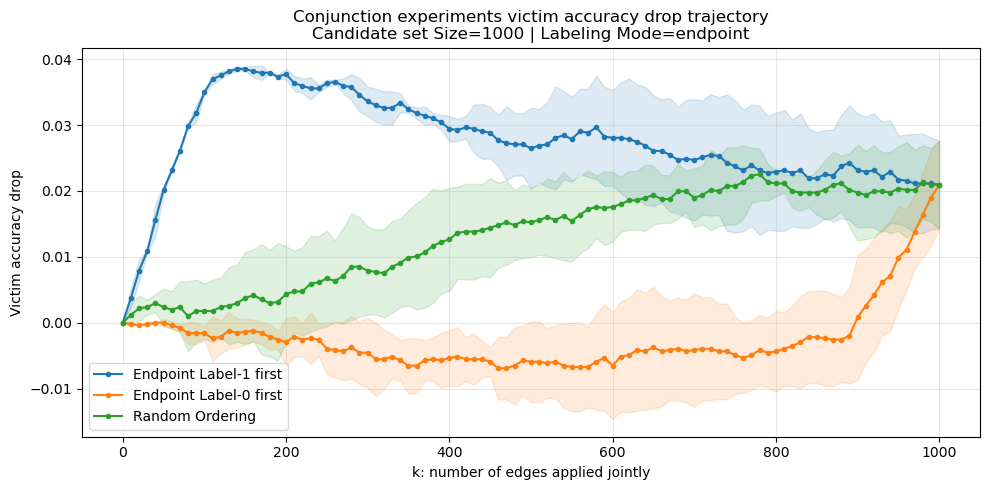

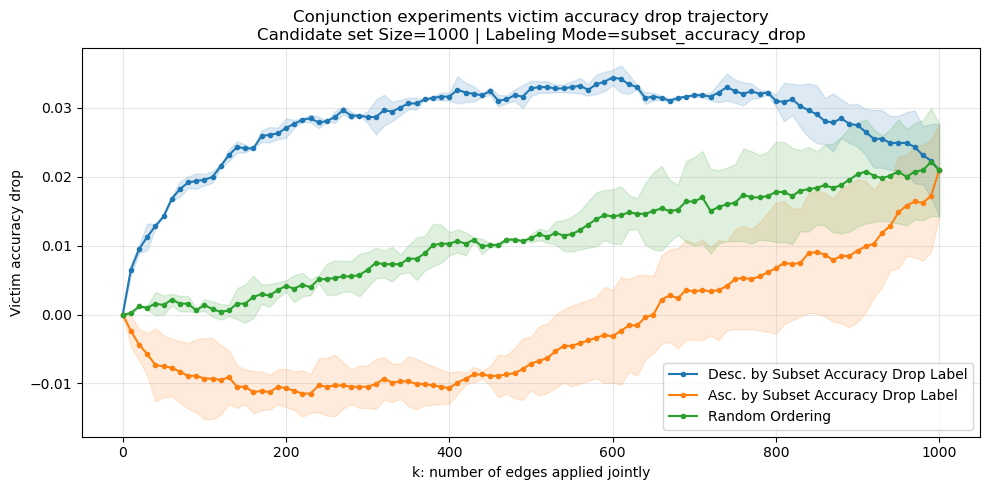

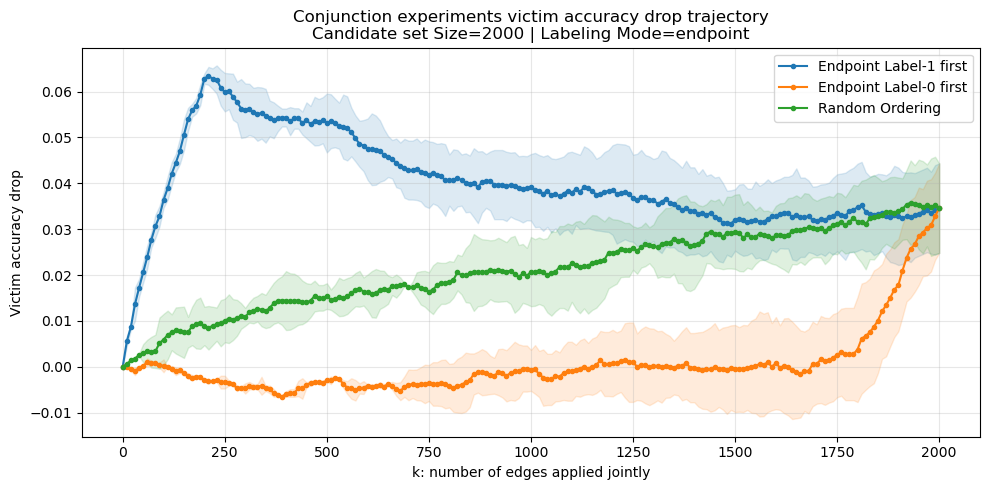

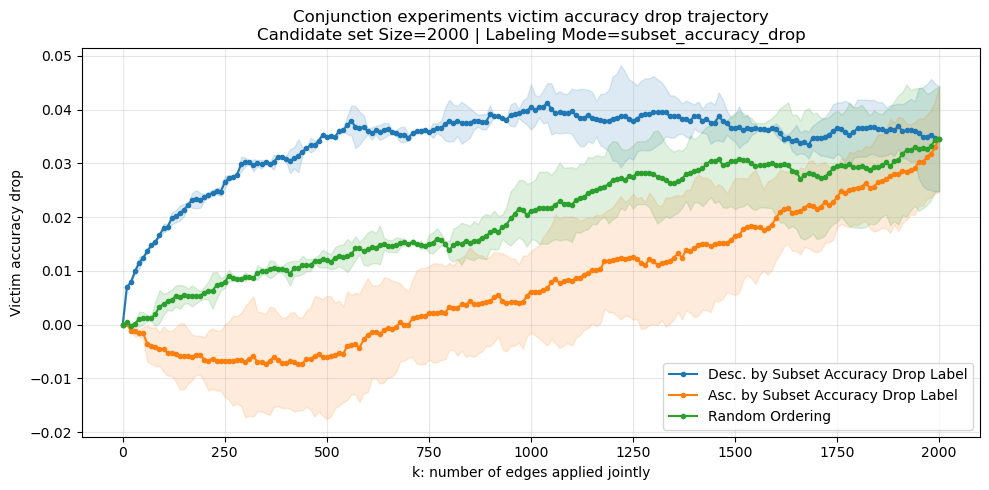

Saved conjunction experiment plots to: E:\Masterarbeit\AttackerGNN\extendedPlotting\final_runs\RQ2\rq2_conjunction_experiment\plots


In [8]:
# ============================================================
# Plot conjunction experiment trajectories
#
# One plot per:
#   candidate_set_size × scoring_mode
#
# y-axis:
#   victim_accuracy_drop
#
# lines:
#   descending / ascending / random
#
# shading:
#   ±1 standard deviation across seeds
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CONJUNCTION_PLOT_DIR = RQ2_CONJUNCTION_EXP_OUT_DIR / "plots"
CONJUNCTION_PLOT_DIR.mkdir(parents=True, exist_ok=True)

conjunction_plot_df = (
    rq2_conjunction_accuracy_raw
    .groupby(["candidate_set_size", "scoring_mode", "ordering", "k"], dropna=False)
    .agg(
        victim_accuracy_drop_mean=("victim_accuracy_drop", "mean"),
        victim_accuracy_drop_std=("victim_accuracy_drop", "std"),
        n_seeds=("seed", "nunique"),
    )
    .reset_index()
)

conjunction_plot_df["victim_accuracy_drop_std"] = (
    conjunction_plot_df["victim_accuracy_drop_std"]
    .fillna(0.0)
)


# ------------------------------------------------------------
# Labels for legend
# ------------------------------------------------------------

ordering_labels = {
    "endpoint_label_desc": "Endpoint Label-1 first",
    "endpoint_label_asc": "Endpoint Label-0 first",
    "subset_score_desc": "Desc. by Subset Accuracy Drop Label",
    "subset_score_asc": "Asc. by Subset Accuracy Drop Label",
    "random": "Random Ordering",
}


# ------------------------------------------------------------
# Plot one figure per candidate_set_size × scoring_mode
# ------------------------------------------------------------

for (candidate_set_size, scoring_mode), frame in conjunction_plot_df.groupby(
    ["candidate_set_size", "scoring_mode"],
    dropna=False,
):

    if scoring_mode == "endpoint":
        ordering_sequence = [
            "endpoint_label_desc",
            "endpoint_label_asc",
            "random",
        ]
    elif scoring_mode == "subset_accuracy_drop":
        ordering_sequence = [
            "subset_score_desc",
            "subset_score_asc",
            "random",
        ]
    else:
        continue

    fig, ax = plt.subplots(figsize=(10, 5))

    for ordering in ordering_sequence:

        ordering_df = frame[frame["ordering"] == ordering].copy()
        ordering_df = ordering_df.sort_values("k")

        x = ordering_df["k"].to_numpy(dtype=float)
        mean = ordering_df["victim_accuracy_drop_mean"].to_numpy(dtype=float)
        std = ordering_df["victim_accuracy_drop_std"].to_numpy(dtype=float)

        line = ax.plot(
            x,
            mean,
            marker="o",
            markersize=3,
            label=ordering_labels.get(ordering, ordering),
        )[0]

        ax.fill_between(
            x,
            mean - std,
            mean + std,
            alpha=0.15,
            color=line.get_color(),
        )

    ax.set_xlabel("k: number of edges applied jointly")
    ax.set_ylabel("Victim accuracy drop")
    ax.set_title(
        f"Conjunction experiments victim accuracy drop trajectory\n"
        f"Candidate set Size={candidate_set_size} | Labeling Mode={scoring_mode}"
    )

    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    safe_mode = "".join(
        c if c.isalnum() or c in "-_" else "_"
        for c in str(scoring_mode)
    )

    fig.savefig(
        CONJUNCTION_PLOT_DIR
        / f"conjunction_experiment__candN-{candidate_set_size}_{DATASET}_{safe_mode}.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


print("Saved conjunction experiment plots to:", CONJUNCTION_PLOT_DIR.resolve())

---

## Experiment 4 — Balanced Label-Conditioned PR-BCD Initialization

### Research objective

RQ1 showed that PR-BCD can only optimize candidates contained in its restricted search block. This experiment tests whether endpoint label-1 candidates define a more useful PR-BCD candidate space than label-0 or random candidates.

Three initial block types are compared:

1. endpoint label-1 candidates;
2. endpoint label-0 candidates;
3. random candidates from the full edge-perturbation space.

The label-conditioned blocks are balanced to a common size:

\[
b
=
\min
\left(
n_{\mathrm{label\,1}},
n_{\mathrm{label\,0}}
\right).
\]

The larger label group is sampled without replacement to match the smaller group. The random control receives the same block size.

This balancing ensures that attack differences cannot be attributed to different numbers of available candidate coordinates.


### Execution block

Each of the three initializations is evaluated under two optimization conditions.

#### Fixed candidate block

The candidate block remains fixed throughout optimization. PR-BCD can update the relaxed weights but cannot introduce new candidate edges.

This condition isolates candidate quality:

> Does a block of locally harmful candidates provide a better restricted optimization space than an equally sized label-0 or random block?

#### Random coordinate resampling

PR-BCD performs its standard WeightOnly retention and random refill procedure.

This condition evaluates whether the initial candidate advantage persists when the attack can introduce new coordinates.

The resulting six conditions are:

1. label 1 with a fixed block;
2. label 1 with random resampling;
3. label 0 with a fixed block;
4. label 0 with random resampling;
5. random initialization with a fixed block;
6. random initialization with random resampling.

Within each victim seed and repeat, the attack configuration and stochastic seeds are paired as closely as possible.

In [9]:
# ============================================================
# RQ2: PRBCD initial-block experiment
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from experiments import experiment_global_attack_direct
from rgnn_at_scale.attacks.prbcd import PRBCD

RQ2_INITIAL_BLOCK_EXP_OUT_DIR = RQ2_OUT_DIR / "rq2_initial_block"
RQ2_INITIAL_BLOCK_EXP_OUT_DIR.mkdir(parents=True,exist_ok=True)

# Experiment Parameters
RQ2_BLOCK_SUBSET_EXTREME_FRACTION = 0.10

# PR-BCD Parameters
RQ2_BLOCK_ATTACK_BUDGET_FRACTION = 0.003
RQ2_BLOCK_EPOCHS = 100
RQ2_BLOCK_RESAMPLING_EPOCHS = 50 # Only when resampling is not disabled

# Helper functions
def _sample_random_candidates(candidates, n, seed):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(candidates), size=n, replace=False)
    return [candidates[i] for i in indices]

def _candidates_to_linear_ids(candidates, n_nodes):
    pairs = torch.tensor(candidates, dtype=torch.long).T
    linear_ids = PRBCD.pairs_to_linear_uppertri(pairs, n_nodes).long()
    return linear_ids

def _to_numpy(values):
    if torch.is_tensor(values):
        return values.detach().cpu().numpy().astype(float).reshape(-1)

    return np.asarray([
        float(torch.as_tensor(value).detach().cpu().item())
        for value in values
    ])


# Run PR-BCD with initial blocks supplied
prbcd_initial_block_rows = []
for run in mining_runs:

    # Initial Block construction required variables
    seed = run["seed"]
    candidate_set_size = run["candidate_set_size"]
    scoring_mode = run["scoring_mode"]
    candidates = list(run["candidates"])

    # PR-BCD required variables
    context = run["context"]
    graph = context["graph"]
    n_nodes = context["n_nodes"]
    n_edges = context["n_edges_undirected"]
    n_possible_edges = context["n_edges_possible"]
    attack_budget = max(1, round(RQ2_BLOCK_ATTACK_BUDGET_FRACTION * n_edges))
    fine_tune_epochs = RQ2_BLOCK_EPOCHS - RQ2_BLOCK_RESAMPLING_EPOCHS

    # Build PR-BCD blocks for both labeling objectives
    if scoring_mode == "endpoint":
        labels = run["labels_changed"].detach().cpu().numpy()
        group_harmful = [
            candidate
            for candidate, label in zip(candidates, labels)
            if label > 0.5
        ]
        group_nonharmful = [
            candidate
            for candidate, label in zip(candidates, labels)
            if label < 0.5
        ]
        block_size = len(group_harmful)
        if len(group_nonharmful) < block_size:
            raise ValueError(
                f"Not enough group_nonharmful candidates for seed={seed}, "
                f"size={candidate_set_size}."
            )
        blocks = {
            "group_harmful": group_harmful,
            "group_nonharmful": _sample_random_candidates(
                group_nonharmful,
                block_size,
                seed,
            ),
        }

    else:
        scores = np.asarray(run["labels_changed"], dtype=float)
        block_size = int(np.floor(RQ2_BLOCK_SUBSET_EXTREME_FRACTION * len(candidates)))
        order = np.argsort(scores)
        blocks = {
            "group_nonharmful": [
                candidates[i]
                for i in order[:block_size]
            ],
            "group_harmful": [
                candidates[i]
                for i in order[-block_size:]
            ],
        }

    # From initial PR-BCD implementation.
    if block_size <= attack_budget:
        raise ValueError(
            f"block_size={block_size} must be larger "
            f"than attack_budget={attack_budget}."
        )

    # Convert blocks to linear ids as in original PR-BCD search space.
    block_as_linear_ids = {block_name: _candidates_to_linear_ids(block_candidates,n_nodes)
        for block_name, block_candidates in blocks.items()
    }

    # Sample random edges like PR-BCD random block sampling
    # Guarantees unique edges and consistent block size
    block_as_linear_ids["group_random"] = torch.randperm(n_possible_edges)[:block_size]

    # Run PR-BCD for harmful, nonharmful and random blocks
    for block_name, linear_ids in block_as_linear_ids.items():
        for resampling_enabled in [True, False]:

            # Pass attack parameters and blocks
            attack_params = {
                "block_size": block_size,
                "epochs": RQ2_BLOCK_EPOCHS,
                "fine_tune_epochs": fine_tune_epochs,
                "with_early_stopping": False,
                "keep_heuristic": "WeightOnly",
                "loss_type": "tanhMargin",
                "initial_block_label": block_name,
                "initial_block_linear_ids": linear_ids,
                "resampling_enabled": resampling_enabled,
                "attack_sampling_seed": seed,
            }

            print(
                f"PRBCD | seed={seed} | label_type={scoring_mode}"
                f"Candidate set size={candidate_set_size} | "
                f"block={block_name} | resampling={resampling_enabled}"
            )

            # Run PR-BCD
            result = experiment_global_attack_direct.run(
                graph=graph,
                data_dir="./data",
                dataset=DATASET,
                attack="PRBCD",
                attack_params=attack_params,
                selector_params={},
                epsilons=[RQ2_BLOCK_ATTACK_BUDGET_FRACTION],
                binary_attr=False,
                make_undirected=True,
                seed=seed,
                artifact_dir="cache",
                pert_adj_storage_type="evasion_global_adj",
                pert_attr_storage_type="evasion_global_attr",
                model_label=MODEL_LABEL,
                model_storage_type="demo_custom_split", # Model storage is bypassed.
                device="cpu",
                data_device="cpu",
                debug_level="info",
                semi=True,
                use_cert="none",
            )

            accuracy_values = result["attack_statistics"]["accuracy"]

            if accuracy_values is None:
                raise RuntimeError(
                    "Could not find PRBCD accuracy trajectory."
                )

            accuracies = _to_numpy(accuracy_values)

            for i, victim_accuracy in enumerate(accuracies):
                prbcd_initial_block_rows.append({
                    "seed": seed,
                    "candidate_set_size": candidate_set_size,
                    "scoring_mode": scoring_mode,
                    "resampling_enabled": resampling_enabled,
                    "block": block_name,
                    "block_size": block_size,
                    "prbcd_epoch": i - 1,
                    "accuracy_drop": run["clean_accuracy"] - victim_accuracy,
                })


rq2_prbcd_block_accuracy_raw = pd.DataFrame(prbcd_initial_block_rows)
display(rq2_prbcd_block_accuracy_raw)

rq2_prbcd_block_accuracy_results = (
    rq2_prbcd_block_accuracy_raw
    .drop(columns="seed")
    .groupby([
        "candidate_set_size",
        "scoring_mode",
        "block",
        "resampling_enabled",
        "prbcd_epoch",
    ])
    .agg(["mean", "std"])
    .reset_index()
)

rq2_prbcd_block_accuracy_results.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in rq2_prbcd_block_accuracy_results.columns
]

display(rq2_prbcd_block_accuracy_results)

rq2_prbcd_block_accuracy_results.to_csv(
    RQ2_INITIAL_BLOCK_EXP_OUT_DIR
    / (
        f"rq2_initial_block_experiment_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

print(f"\nSaved to: {RQ2_INITIAL_BLOCK_EXP_OUT_DIR.resolve()}")

PRBCD | seed=0 | label_type=endpointCandidate set size=1000 | block=group_harmful | resampling=True


[08/16/26 21:49:17] INFO     {'dataset': 'cora_ml', 'attack': 'PRBCD', 'attack_params': {'block_size': ]8;id=125509;file://E:\Masterarbeit\AttackerGNN\experiments\common.py\common.py]8;;\:]8;id=410212;file://E:\Masterarbeit\AttackerGNN\experiments\common.py#38\38]8;;\
                             105, 'epochs': 100, 'fine_tune_epochs': 50, 'with_early_stopping': False,             
                             'keep_heuristic': 'WeightOnly', 'loss_type': 'tanhMargin',                            
                             'initial_block_label': 'group_harmful', 'initial_block_linear_ids':                   
                             tensor([2656539,  313957,  815038, 2710462, 3501717,  851752, 3770204,                
                             3587729,                                                                              
                                     3436083, 3637056, 1402973,  943672, 2359841, 2808526, 1984377,                
                             3096874,                                                                              
                                     1230509, 1212209, 2873915,  206087,  599430, 2203027,  792791,                
                             2482260,                                                                              
                                      902212,  593736,  934037, 1276562, 1481167, 2647864,  890604,                
                             3585694,                                                                              
                                     1310197, 1872568, 1305759, 2385588, 3184511, 2687219, 2991500,                
                             3065508,                                                                              
                                      632432, 3388280, 2148655, 3560680, 3361461, 1486136, 1526939,                
                             2827297,                                                                              
                                      839003, 1513241, 1510075, 2662911, 3130144, 2663184,  110393,                
                             2247941,                                                                              
                                     2852973, 2855094, 2293116,  408108, 1167528, 2242168, 3660490,                
                             566336,                                                                               
                                     1939347, 3560416, 2310464,  953936,  939711, 2775936, 3587367,                
                             1260699,                                                                              
                                     3622987, 1400959, 3637300, 2151874, 2731135, 2203239, 1355574,                
                             3578416,                                                                              
                                     3458609,  833455, 3154029, 2646399,  915226, 3659976, 3301710,                
                             2641029,                                                                              
                                     1310079, 3346831,  901228,  270673, 1702517,  546208,   36704,                
                             3099832,                                                                              
                                     2896469,  992110, 2830303, 2132605, 2657647, 2367948, 2206656,                
                             212339,                                                                               
                                     1841359]), 'resampling_enabled': True, 'attack_sampling_seed':                
                             0}, 'epsilons': [0.003], 'make_undirected': True, 'binary_attr': False,               
                             'seed': 0, 'artifact_dir': 'cache', 'pert_adj_storage_type':                          
           

                    INFO     Lock 3065746146640 acquired on cache\demo_custom_split.json.lock       ]8;id=38159;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=634917;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 3065746146640 released on cache\demo_custom_split.json.lock       ]8;id=129913;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=502512;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

                    INFO     Evaluate PRBCD for model 'GCN'.                 ]8;id=23889;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_global_attack_direct.py\experiment_global_attack_direct.py]8;;\:]8;id=570672;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_global_attack_direct.py#116\116]8;;\

...

[08/16/26 22:03:19] INFO                                                                               ]8;id=829783;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\attacks\prbcd.py\prbcd.py]8;;\:]8;id=468418;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\attacks\prbcd.py#331\331]8;;\
                             Epoch: 20 Loss: -0.6519914865493774 Accuracy: 83.241 %                                
                                                                                                                   

 40%|████      | 40/100 [00:34<00:51,  1.17it/s]

[08/16/26 22:03:36] INFO                                                                               ]8;id=520748;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\attacks\prbcd.py\prbcd.py]8;;\:]8;id=963937;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\attacks\prbcd.py#331\331]8;;\
                             Epoch: 40 Loss: -0.6512326002120972 Accuracy: 83.202 %                                
                                                                                                                   

 41%|████      | 41/100 [00:35<00:50,  1.17it/s]

KeyboardInterrupt: 

### Analysis and plotting block

The following cell evaluates attack strength, optimization dynamics, and block retention.

#### Attack outcomes

The analysis reports:

- final attacked accuracy;
- final accuracy drop;
- minimum relaxed accuracy;
- maximum relaxed accuracy drop;
- integrated accuracy drop;
- number of epochs required to reach fixed accuracy reductions.

#### Candidate utilization

The analysis also reports:

- fraction of final perturbations originating from the initial block;
- fraction of final perturbations carrying label 1;
- fraction of final perturbations carrying label 0;
- retention of the original block over optimization epochs;
- label composition of the final candidate block;
- label composition of the final discrete perturbation set.

#### Main comparisons

The paired comparisons are:

\[
\text{label 1}
\quad\text{versus}\quad
\text{label 0},
\]

\[
\text{label 1}
\quad\text{versus}\quad
\text{random},
\]

and

\[
\text{fixed block}
\quad\text{versus}\quad
\text{random resampling}.
\]

This experiment connects local harmfulness directly to the candidate-coverage limitation identified in RQ1.

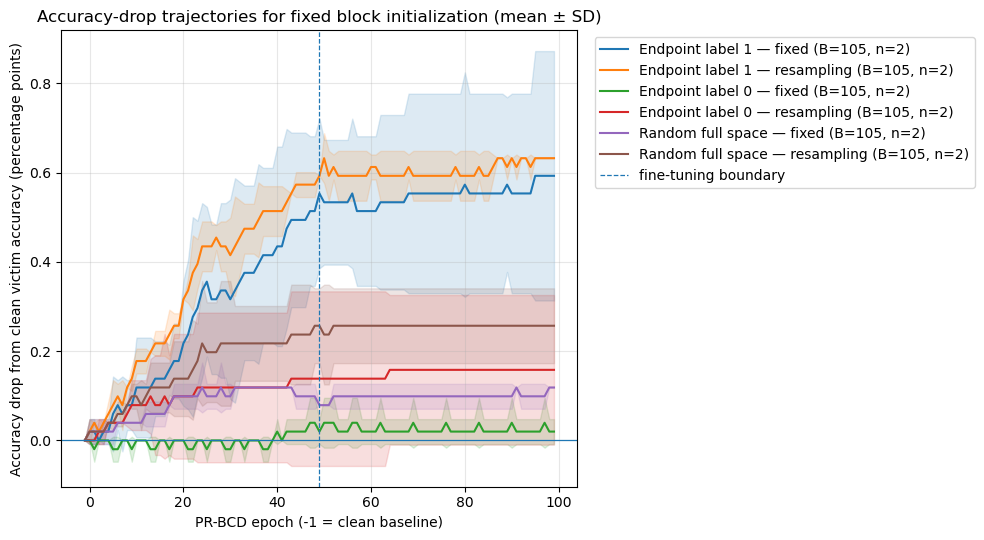

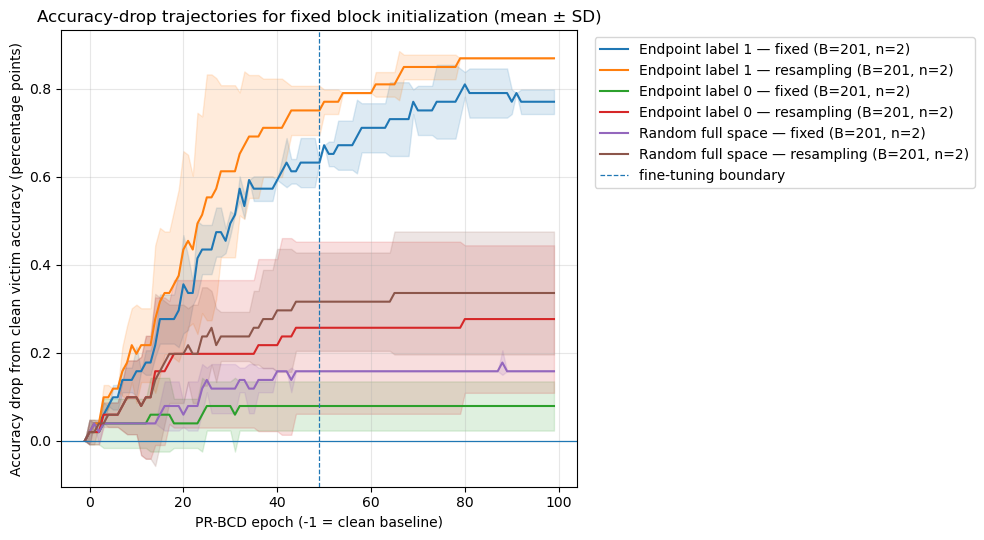

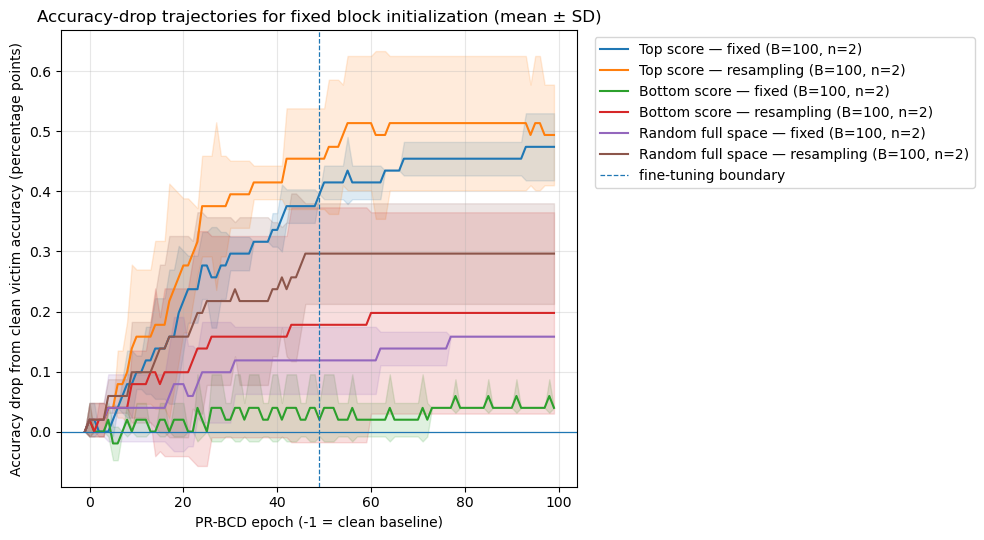

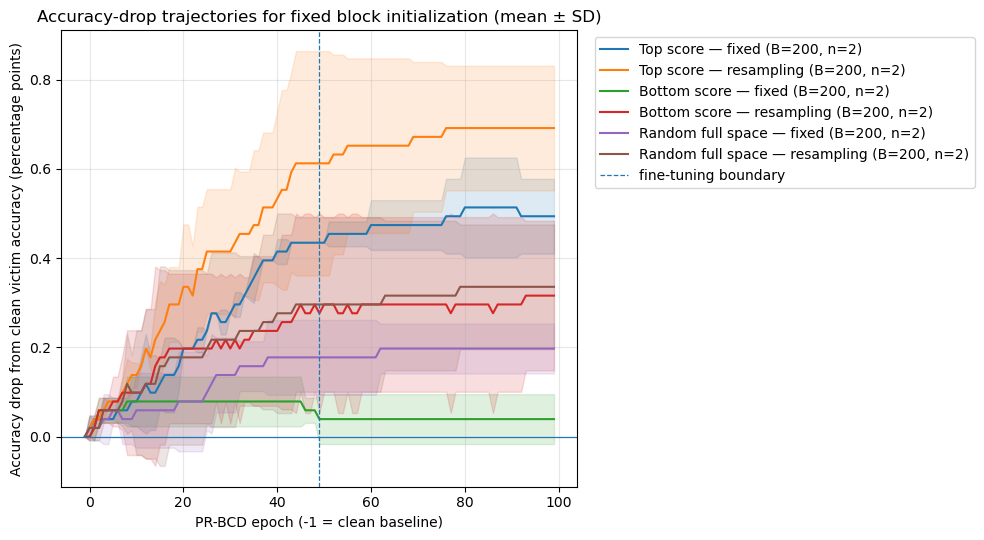

In [10]:
# ============================================================
# RQ2: Plot PRBCD initial-block trajectories
# ============================================================

import matplotlib.pyplot as plt

RQ2_INITIAL_BLOCK_PLOT_DIR = RQ2_INITIAL_BLOCK_EXP_OUT_DIR / "plots"
RQ2_INITIAL_BLOCK_PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Mean and standard deviation across seeds
trajectory_summary = (
    rq2_prbcd_block_accuracy_raw
    .groupby([
        "candidate_set_size",
        "scoring_mode",
        "block",
        "resampling_enabled",
        "prbcd_epoch",
    ])["accuracy_drop"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

for scoring_mode in ["endpoint", "subset_accuracy_drop"]:

    frame = trajectory_summary[trajectory_summary["scoring_mode"] == scoring_mode]

    for candidate_set_size, size_df in frame.groupby("candidate_set_size"):

        fig, ax = plt.subplots(figsize=(10, 5.5))

        for (block, resampling_enabled), condition_df in size_df.groupby([
            "block",
            "resampling_enabled",
        ]):

            condition_df = condition_df.sort_values("prbcd_epoch")

            if scoring_mode == "endpoint":
                block_label = {
                    "group_harmful": "Endpoint label 1",
                    "group_nonharmful": "Endpoint label 0",
                    "group_random": "Random full space",
                }[block]
            else:
                block_label = {
                    "group_harmful": "Top score",
                    "group_nonharmful": "Bottom score",
                    "group_random": "Random full space",
                }[block]

            resampling_label = (
                "resampling"
                if resampling_enabled
                else "fixed"
            )

            block_size = int(
                rq2_prbcd_block_accuracy_raw.loc[
                    (rq2_prbcd_block_accuracy_raw["candidate_set_size"] == candidate_set_size)
                    & (rq2_prbcd_block_accuracy_raw["scoring_mode"] == scoring_mode)
                    & (rq2_prbcd_block_accuracy_raw["block"] == block),
                    "block_size",
                ].iloc[0]
            )

            n_seeds = int(condition_df["count"].max())

            label = (
                f"{block_label} — {resampling_label} "
                f"(B={block_size}, n={n_seeds})"
            )

            x = condition_df["prbcd_epoch"].to_numpy()
            mean = condition_df["mean"].to_numpy() * 100
            std = condition_df["std"].fillna(0).to_numpy() * 100

            line = ax.plot(
                x,
                mean,
                label=label,
            )[0]

            ax.fill_between(
                x,
                mean - std,
                mean + std,
                alpha=0.15,
                color=line.get_color(),
            )

        ax.axvline(
            RQ2_BLOCK_RESAMPLING_EPOCHS - 1,
            linestyle="--",
            linewidth=0.9,
            label="fine-tuning boundary",
        )

        ax.axhline(
            0,
            linewidth=0.9,
        )

        ax.set_xlabel("PR-BCD epoch (-1 = clean baseline)")
        ax.set_ylabel("Accuracy drop from clean victim accuracy ""(percentage points)")
        ax.set_title("Accuracy-drop trajectories for fixed block initialization (mean ± SD)")

        ax.grid(
            True,
            alpha=0.3,
        )

        ax.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )

        plot_path = (
            RQ2_INITIAL_BLOCK_PLOT_DIR
            / f"rq2_initial_block_{DATASET}_{scoring_mode}_candN-{candidate_set_size}.png"
        )

        fig.savefig(
            plot_path,
            dpi=300,
            bbox_inches="tight",
        )

        fig.tight_layout()
        plt.show()

---

# RQ2 Synthesis — From Individual Harmfulness to PR-BCD Usefulness

The RQ2 experiments investigate progressively stronger notions of harmfulness.

## 1. Individual harmfulness

Direct mining determines whether an edge causes observable damage when evaluated individually.

Endpoint mining captures local harmfulness:

\[
e
\rightarrow
H_{\mathrm{loc}}(e;G).
\]

Accuracy-drop mining captures an individual global effect:

\[
e
\rightarrow
A(G)-A(G\oplus e).
\]

## 2. Conditional harmfulness under joint perturbations

The oracle experiment determines whether mined candidates continue to contribute damage after other perturbations have already been applied:

\[
e
\rightarrow
H_{\mathrm{cond}}(e\mid B;G).
\]

This separates conditionally harmful, neutral, and cancelling additions.

## 3. Conditional harmfulness during optimization

The injection experiment evaluates whether a mined candidate remains useful inside an evolving PR-BCD state:

\[
e
\rightarrow
H_{\mathrm{inj}}(e\mid S_t).
\]

This measures harmfulness under the current block composition, relaxed weights, and optimization history.

## 4. Candidate-space usefulness

The balanced initialization experiment evaluates whether local harmfulness information improves the restricted PR-BCD search space:

\[
H_{\mathrm{loc}}
\rightarrow
\text{label-informed block}
\rightarrow
\text{PR-BCD attack effectiveness}.
\]

Together, the experiments test the chain

\[
\boxed{
\text{individually harmful}
\rightarrow
\text{conditionally harmful}
\rightarrow
\text{useful as a PR-BCD candidate}
}
\]

The results also decompose candidate-block quality into two components:

\[
\boxed{
\text{candidate coverage}
+
\text{candidate compatibility}
}
\]

Endpoint label-1 initialization primarily addresses candidate coverage. The oracle and injection experiments examine whether the selected candidates remain compatible and harmful under joint or algorithmic conditions.

## Construct and persist the RQ3 source-subgraph candidate-mining sweep

This block now uses two independent cache layers:

1. **Candidate-pool cache:** stores the selected source nodes and the maximum
   sampled candidate pool once per victim seed, subgraph method, subgraph seed,
   and subgraph fraction.
2. **Label cache:** stores the expensive victim-query labels once per exact
   candidate size and scoring mode.

The sweep is resumable at configuration level: existing artifacts are loaded
individually, and only missing or explicitly invalidated configurations are
computed again. Progress is written continuously to a CSV manifest.


### Whole-graph selector condition (`subgraph_fraction = 1.0`)

When the requested fraction is `1.0`, the pipeline uses every graph node and every structural edge for selector message passing. Candidate pairs are still sampled from the complete upper-triangular pair space and labeled with the same resumable per-configuration cache. `subgraph_seed` remains useful as an independent candidate-pool sampling replicate; the graph itself is not resampled.


In [11]:
from helpers.selector_pipeline_helpers import train_selector
import torch

RQ3_SELECTOR_TRAINING_STATS_OUT_DIR = RQ3_OUT_DIR / "rq3_selector_training_stats"
RQ3_SELECTOR_TRAINING_STATS_OUT_DIR.mkdir(parents=True, exist_ok=True)

selector_training_rows = []
for run in mining_runs:

    context = run["context"]
    device = context["attr"].device

    attr = context["attr"].to(device)
    edge_index_struct = context["edge_index"]

    # Construct edge index tensor of labeled candidate edges
    src = run["src"].long().to(device)
    dst = run["dst"].long().to(device)
    edge_index_lab = torch.stack([src, dst],dim=0)

    # Extract label vector for labeled candidate edges
    y_label = run["labels_changed"]
    print(
        f"\nTraining selector | "
        f"seed={run['seed']} | "
        f"candidates={run['candidate_set_size']} | "
        f"mode={run['scoring_mode']} | "
        f"training pairs={y_label.numel()}"
    )

    # Train Selector
    selector_model = train_selector(
        attr=attr,
        edge_index_struct=edge_index_struct,
        edge_index_lab=edge_index_lab,
        y_label=y_label,
        label_mode=run["scoring_mode"],
        device=device,
        num_epochs=SCORER_EPOCHS,
        hidden_dim=SCORER_HIDDEN,
        out_dim=SCORER_HIDDEN,
        lr=SCORER_LR,
        weight_decay=5e-4,
        early_stop=True,
        min_epochs_before_early_stop=300,
        patience=PATIENCE,
        split_ratios=(0.70, 0.15, 0.15),
    )

    history = selector_model.training_history

    # Log Train and Validation Losses for later plotting
    for epoch, (train_loss, val_loss) in enumerate(
        zip(history["train_losses"], history["val_losses"]),
        start=1,
    ):
        selector_training_rows.append({
            "seed": run["seed"],
            "candidate_set_size": run["candidate_set_size"],
            "scoring_mode": run["scoring_mode"],
            "epoch": epoch,
            "train_loss": train_loss,
            "validation_loss": val_loss,
            "best_epoch": history["best_epoch"],
            "is_best_epoch": epoch == history["best_epoch"],
        })

    run["selector_model"] = selector_model

    run["edge_index_lab"] = edge_index_lab.detach().cpu()
    run["y_label"] = y_label.detach().cpu()

selector_training_stats_raw = pd.DataFrame(selector_training_rows)
display(selector_training_stats_raw)

# ------------------------------------------------------------
# Aggregate training trajectories across seeds
# ------------------------------------------------------------

selector_training_stats_results = (
    selector_training_stats_raw
    .groupby([
        "candidate_set_size",
        "scoring_mode",
        "epoch",
    ])
    .agg(
        train_loss_mean=("train_loss", "mean"),
        train_loss_std=("train_loss", "std"),
        validation_loss_mean=("validation_loss", "mean"),
        validation_loss_std=("validation_loss", "std"),
        n_seeds=("seed", "nunique"),
    )
    .reset_index()
)

display(selector_training_stats_results)

selector_training_stats_raw.to_csv(
    RQ3_SELECTOR_TRAINING_STATS_OUT_DIR
    / (
        f"rq3_selector_training_stats_raw_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

selector_training_stats_results.to_csv(
    RQ3_SELECTOR_TRAINING_STATS_OUT_DIR
    / (
        f"rq3_selector_training_stats_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

print(
    f"\nSaved selector training statistics to: "
    f"{RQ3_SELECTOR_TRAINING_STATS_OUT_DIR.resolve()}"
)



Training selector | seed=0 | candidates=1000 | mode=endpoint | training pairs=1000
[LP-GNN] Epoch 001/200 | train_loss=1.4444 | val_loss=1.2460 |  | early_stopping_metric=val_ap | current_best=0.1613 | patience_left=20 | new_best
[LP-GNN] Epoch 020/200 | train_loss=0.8110 | val_loss=1.2505 |  | early_stopping_metric=val_ap | current_best=0.2818 | patience_left=20
[LP-GNN] Epoch 040/200 | train_loss=0.7933 | val_loss=1.3328 |  | early_stopping_metric=val_ap | current_best=0.2818 | patience_left=19
Selector Training stopping at epoch 59. Best early_stopping_metric=0.2818 at epoch 17.

Training selector | seed=0 | candidates=1000 | mode=subset_accuracy_drop | training pairs=1000
[LP-GNN] Epoch 001/200 | train_loss=0.6929 | val_loss=0.6831 |  | early_stopping_metric=val_loss | current_best=0.6831 | patience_left=20 | new_best
[LP-GNN] Epoch 020/200 | train_loss=0.6736 | val_loss=0.6737 |  | early_stopping_metric=val_loss | current_best=0.6735 | patience_left=20
[LP-GNN] Epoch 040/200 | tr

,seed,candidate_set_size,scoring_mode,epoch,train_loss,validation_loss,best_epoch,is_best_epoch
0,0,1000,endpoint,1,1.444414,1.246009,17,False
1,0,1000,endpoint,2,1.425596,1.262934,17,False
2,0,1000,endpoint,3,1.400548,1.289213,17,False
3,0,1000,endpoint,4,1.374148,1.261007,17,False
4,0,1000,endpoint,5,1.325208,1.239959,17,False
...,...,...,...,...,...,...,...,...
501,1,2000,subset_accuracy_drop,55,0.688166,0.687349,3,False
502,1,2000,subset_accuracy_drop,56,0.688166,0.687349,3,False
503,1,2000,subset_accuracy_drop,57,0.688166,0.687349,3,False
504,1,2000,subset_accuracy_drop,58,0.688166,0.687348,3,False


,candidate_set_size,scoring_mode,epoch,train_loss_mean,train_loss_std,validation_loss_mean,validation_loss_std,n_seeds
0,1000,endpoint,1,1.423359,0.029776,1.241413,0.006499,2
1,1000,endpoint,2,1.408303,0.024456,1.256290,0.009395,2
2,1000,endpoint,3,1.387940,0.017831,1.277262,0.016901,2
3,1000,endpoint,4,1.363751,0.014703,1.249668,0.016036,2
4,1000,endpoint,5,1.318561,0.009401,1.225844,0.019961,2
...,...,...,...,...,...,...,...,...
265,2000,subset_accuracy_drop,55,0.683063,0.007216,0.682648,0.006649,2
266,2000,subset_accuracy_drop,56,0.683064,0.007215,0.682648,0.006648,2
267,2000,subset_accuracy_drop,57,0.683065,0.007214,0.682648,0.006648,2
268,2000,subset_accuracy_drop,58,0.683065,0.007214,0.682647,0.006649,2



Saved selector training statistics to: E:\Masterarbeit\AttackerGNN\extendedPlotting\final_runs\RQ3\rq3_selector_training_stats


### RQ3 selector-training statistics across the complete subgraph sweep

The following diagnostic cells evaluate every trained selector in `RQ3_SUBGRAPH_TRAINING_RUNS`. The later fixed-block experiment still uses only the configured primary selector through `lp_training_runs`, while §8 uses the complete selector registry.


In [12]:
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    r2_score,
    ndcg_score,
)

# Generated by ChatGPT 5.1
# Calculates pearson Correlation
def safe_correlation(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 2:
        return np.nan

    if np.std(x) <= 1e-12 or np.std(y) <= 1e-12:
        return np.nan

    return float(np.corrcoef(x, y)[0, 1])

# Generated by ChatGPT 5.1
# Calculates Spearman Correlation
def spearman_correlation(x, y):
    x_rank = pd.Series(x).rank(method="average").to_numpy()
    y_rank = pd.Series(y).rank(method="average").to_numpy()

    return safe_correlation(x_rank, y_rank)

RQ3_SELECTOR_TEST_METRICS = RQ3_OUT_DIR / "rq3_selector_test_metrics"
RQ3_SELECTOR_TEST_METRICS.mkdir(parents=True, exist_ok=True)

# ============================================================
# Evaluate untouched test sets
# ============================================================

selector_on_test_rows = []

for run in mining_runs:

    model = run["selector_model"]
    history = model.training_history
    device = next(model.parameters()).device
    context = run["context"]
    attr = context["attr"].to(device)

    edge_index_struct = context["edge_index"].long().to(device)
    src = run["src"].long().to(device)
    dst = run["dst"].long().to(device)
    candidates = torch.stack([src, dst], dim=0)

    y_labels = run["labels_changed"].float().to(device)
    test_idx = history["test_idx"].long().to(device)
    candidates_test = candidates[:, test_idx]
    y_labels_test = y_labels[test_idx].numpy()

    # Evaluate Selector on Test Set
    model.eval()
    with torch.no_grad():
        logits_test = model(attr, edge_index_struct, candidates_test).view(-1)
        scores_test = torch.sigmoid(logits_test)

    y_score = scores_test.detach().cpu().numpy()

    # Endpoint ranking evaluation for selector scores
    if run["scoring_mode"] == "endpoint":

        # Straight forward
        ap = average_precision_score(y_labels_test, y_score)
        roc_auc = roc_auc_score(y_labels_test, y_score)

        # take top 10% of scores for precision@k
        k = max(1, int(0.10 * len(y_score)))
        ranked_idx = np.argsort(y_score)[::-1].copy()
        top_k_idx = ranked_idx[:k]

        # Fraction of test candidates labeled 1
        label_1_rate = float(y_labels_test.mean())

        # Fraction of label-1 edges among the top-k scored candidates
        precision_at_k = float(y_labels_test[top_k_idx].mean())

        # Enrichment of top 10% compared to the actual rate
        lift_at_k = precision_at_k / label_1_rate

        row = {
            "seed": run["seed"],
            "candidate_set_size": run["candidate_set_size"],
            "scoring_mode": run["scoring_mode"],
            "test_pairs": len(y_labels_test),
            "label_1_rate": label_1_rate,
            "ap": float(ap),
            "roc_auc": float(roc_auc),
            "k": k,
            "precision_at_k": precision_at_k,
            "lift_at_k": float(lift_at_k),
        }


    # Regression metrics for subset accuracy drop scores
    else:
        # take top 10% of scores for NDCG@k
        k = max(1, int(0.10 * len(y_score)))

        ndcg_at_k = ndcg_score(y_labels_test.reshape(1, -1), y_score.reshape(1, -1), k=k)

        row = {
            "seed": run["seed"],
            "candidate_set_size": run["candidate_set_size"],
            "scoring_mode": run["scoring_mode"],
            "test_pairs": len(y_labels_test),
            "pearson": safe_correlation(y_labels_test, y_score),
            "spearman": spearman_correlation(y_labels_test, y_score),
            "r2": r2_score(y_labels_test, y_score),
            "target_sd": np.std(y_labels_test, ddof=0),
            "prediction_sd": np.std(y_score, ddof=0),
            "k": k,
            "ndcg_at_k": float(ndcg_at_k),
        }

    # Attach the results to the corresponding trained selector
    run["selector_test_results"] = row
    selector_on_test_rows.append(row)


# Log and save results
selector_metrics_on_test_raw = pd.DataFrame(selector_on_test_rows)

selector_metrics_on_test_results = (
    selector_metrics_on_test_raw
    .drop(columns="seed")
    .groupby(["candidate_set_size", "scoring_mode"])
    .agg(["mean", "std"])
    .reset_index()
)

selector_metrics_on_test_results.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in selector_metrics_on_test_results.columns
]

selector_metrics_on_test_results.to_csv(
    RQ3_OUT_DIR
    / (
        f"rq3_diagnostic_statistics_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

display(selector_metrics_on_test_results)

,candidate_set_size,scoring_mode,test_pairs_mean,test_pairs_std,label_1_rate_mean,label_1_rate_std,ap_mean,ap_std,roc_auc_mean,roc_auc_std,...,spearman_mean,spearman_std,r2_mean,r2_std,target_sd_mean,target_sd_std,prediction_sd_mean,prediction_sd_std,ndcg_at_k_mean,ndcg_at_k_std
0,1000,endpoint,150.0,0.0,0.106667,0.009428,0.274454,0.069719,0.651766,0.099049,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000,subset_accuracy_drop,150.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.081297,0.007259,0.005303,0.003798,0.12166,0.040693,0.007930,0.000177,0.612996,0.046327
2,2000,endpoint,300.0,0.0,0.100000,0.000000,0.178988,0.011855,0.645247,0.005151,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000,subset_accuracy_drop,300.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.045872,0.025687,-0.000574,0.001634,0.13575,0.001484,0.001672,0.000983,0.630898,0.066234


In [19]:
# ============================================================
# RQ3: Selector conjunction experiment
#
# selector:
#   highest selector score first vs random
#
# Same principle as the RQ2 conjunction experiment:
#   1. take a fixed candidate pool
#   2. define an ordering
#   3. cumulatively flip candidates
#   4. measure victim accuracy drop
# ============================================================

from helpers.selector_pipeline_helpers import accuracy, _edge_set
from tqdm.auto import tqdm
from torch_sparse import SparseTensor

from pathlib import Path
from IPython.display import display

import random
import numpy as np
import pandas as pd
import torch


# ============================================================
# Configuration
# ============================================================

BLOCK_STEP_SELECTOR_CONJUNCTION = 10

# New candidate pool used only for evaluating the trained selectors.
shared_cand_set_size = 10_000

# Same candidate pool for every mining run.
selector_conjunction_seed = 20

# Same random ordering for every mining run.
conjunction_random_ord_seed = 10

RQ3_SELECTOR_CONJUNCTION_OUT_DIR = RQ3_OUT_DIR / "rq3_selector_conjunction_experiment"
RQ3_SELECTOR_CONJUNCTION_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Sample shared oracle candidate pool
# ============================================================

def sample_random_candidates(num_nodes: int, count: int, *, seed: int,):
    """Sample candidate edges"""
    rng = random.Random(int(seed))
    sampled = set()
    while len(sampled) < count:
        u = rng.randrange(num_nodes)
        v = rng.randrange(num_nodes)
        if u == v:
            continue
        sampled.add((min(u, v), max(u, v)))
    return sampled


# All mining runs operate on the same underlying dataset.
n_nodes = mining_runs[0]["context"]["n_nodes"]

shared_candidate_set = sample_random_candidates(n_nodes, shared_cand_set_size, seed=selector_conjunction_seed)
shared_candidates = list(shared_candidate_set)

rng = random.Random(conjunction_random_ord_seed)
rng.shuffle(shared_candidates)

shared_candidates_tensor = torch.tensor(shared_candidates, dtype=torch.long).t().contiguous()

# ============================================================
# Helper: flip one candidate on SparseTensor adjacency
# ============================================================

# Flips one edge from the candidate set identified by the index
def _flip_candidate_sparse(adj, candidates, exists, candidate_index):
    u, v = candidates[candidate_index]
    flip_value = -1.0 if exists[candidate_index] else 1.0
    change = SparseTensor(
        row=torch.tensor([u, v], device=adj.device()),
        col=torch.tensor([v, u], device=adj.device()),
        value=torch.tensor([flip_value, flip_value], device=adj.device()),
        sparse_sizes=adj.sparse_sizes(),
    )
    return (adj + change).coalesce()


# ============================================================
# Run selector conjunction experiment
# ============================================================

selector_conjunction_rows = []
for run_index, run in enumerate(mining_runs):

    seed = run["seed"]
    candidate_set_size = run["candidate_set_size"]
    label_mode = run["scoring_mode"]

    context = run["context"]
    edge_index_struct = context["edge_index"]
    attr = context["attr"]
    clean_adj = context["adj_matrix"].clone()
    victim_idx_test = context["idx_test"]
    victim_labels = context["labels"]
    victim_model = context["model"]
    victim_clean_acc = run["clean_accuracy"]

    selector = run["selector_model"]

    exists = np.array([bool(clean_adj[u, v] == 1) for u, v in shared_candidates])

    # Score conjunction candidate set once
    selector.eval()
    with torch.no_grad():
        selector_logits = selector(attr, edge_index_struct, shared_candidates_tensor)
        selector_scores = torch.sigmoid(selector_logits).view(-1)

    orders = {
        # Highest to lowest scoring edges.
        "selector_score_desc": np.argsort(-selector_scores),
        # shared_candidates is already shuffled.
        "random": np.arange(len(shared_candidates))
    }

    block_sizes = list(range(BLOCK_STEP_SELECTOR_CONJUNCTION,
                             shared_cand_set_size + 1,
                             BLOCK_STEP_SELECTOR_CONJUNCTION))

    # Ensures compatability with candidate sets where
    # shared_cand_set_size % BLOCK_STEP_SELECTOR_CONJUNCTION != 0
    if not block_sizes or block_sizes[-1] != shared_cand_set_size:
        block_sizes.append(shared_cand_set_size)

    for ordering_name, order in (orders.items()):
        # Reset adjacency
        adj = clean_adj.clone()
        previous_k = 0

        # Same as RQ2 :
        # Init first victim accuracy drop with 0.
        selector_conjunction_rows.append({
            "seed": seed,
            "candidate_set_size": candidate_set_size,
            "shared_cand_set_size": shared_cand_set_size,
            "label_mode": label_mode,
            "ordering":ordering_name,
            "k": 0,
            "victim_accuracy_drop": 0.0,
        })

        for k in tqdm(block_sizes, desc=(
                f"seed={seed}, "
                f"train_size={candidate_set_size}, "
                f"mode={label_mode}, "
                f"order={ordering_name}")):
            for candidate_index in (order[previous_k:k]):
                # Flip one candidate
                adj = _flip_candidate_sparse(adj, shared_candidates, exists, candidate_index)

            # Compute victim accuracy after cumulated flips
            victim_accuracy = accuracy(victim_model, attr, victim_labels, victim_idx_test, adj)

            # Compute accuracy drop after cumulated flips
            victim_accuracy_drop = victim_clean_acc - victim_accuracy

            selector_conjunction_rows.append({
                "seed": seed,
                "candidate_set_size": candidate_set_size,
                "shared_cand_set_size": shared_cand_set_size,
                "label_mode": label_mode,
                "ordering": ordering_name,
                "k": k,
                "victim_accuracy_drop": victim_accuracy_drop
            })
            previous_k = k


rq3_selector_conjunction_raw = pd.DataFrame(selector_conjunction_rows)
display(rq3_selector_conjunction_raw)

rq3_selector_conjunction_results = (
    rq3_selector_conjunction_raw
    .groupby(["candidate_set_size" ,"shared_cand_set_size", "label_mode", "ordering","k"],
        as_index=False,
    )
    .agg(
        victim_accuracy_drop_mean=("victim_accuracy_drop","mean"),
        victim_accuracy_drop_std=("victim_accuracy_drop","std"),
        n_seeds=("seed","nunique"),
    )
)
display(rq3_selector_conjunction_results)

candidate_sizes_string = "-".join(map(str, sorted({run["candidate_set_size"] for run in mining_runs})))
seed_string = "-".join(map(str, sorted({ run["seed"] for run in mining_runs})))

results_path = (RQ3_SELECTOR_CONJUNCTION_OUT_DIR
    / (
        f"rq3_selector_conjunction_{DATASET}"
        f"_traincandidates{candidate_sizes_string}"
        f"_seeds{seed_string}.csv"
    )
)

rq3_selector_conjunction_results.to_csv(results_path,index=False)

print(
    "Saved results to:",
    results_path.resolve(),
)

torch.Size([10000])



torch.Size([10000])



torch.Size([10000])



torch.Size([10000])



torch.Size([10000])


...


torch.Size([10000])



torch.Size([10000])


,seed,candidate_set_size,shared_cand_set_size,label_mode,ordering,k,victim_accuracy_drop
0,0,1000,10000,endpoint,selector_score_desc,0,0.000000
1,0,1000,10000,endpoint,selector_score_desc,10,0.001976
2,0,1000,10000,endpoint,selector_score_desc,20,0.002767
3,0,1000,10000,endpoint,selector_score_desc,30,0.003557
4,0,1000,10000,endpoint,selector_score_desc,40,0.004743
...,...,...,...,...,...,...,...
16011,1,2000,10000,subset_accuracy_drop,random,9960,0.056126
16012,1,2000,10000,subset_accuracy_drop,random,9970,0.056917
16013,1,2000,10000,subset_accuracy_drop,random,9980,0.057312
16014,1,2000,10000,subset_accuracy_drop,random,9990,0.057312


,candidate_set_size,shared_cand_set_size,label_mode,ordering,k,victim_accuracy_drop_mean,victim_accuracy_drop_std,n_seeds
0,1000,10000,endpoint,random,0,0.000000,0.000000,2
1,1000,10000,endpoint,random,10,0.000988,0.000280,2
2,1000,10000,endpoint,random,20,0.002174,0.000280,2
3,1000,10000,endpoint,random,30,0.001976,0.001118,2
4,1000,10000,endpoint,random,40,0.001581,0.001118,2
...,...,...,...,...,...,...,...,...
8003,2000,10000,subset_accuracy_drop,selector_score_desc,9960,0.052767,0.007546,2
8004,2000,10000,subset_accuracy_drop,selector_score_desc,9970,0.051779,0.008385,2
8005,2000,10000,subset_accuracy_drop,selector_score_desc,9980,0.051976,0.008105,2
8006,2000,10000,subset_accuracy_drop,selector_score_desc,9990,0.051976,0.008664,2


Saved results to: E:\Masterarbeit\AttackerGNN\extendedPlotting\final_runs\RQ3\rq3_selector_conjunction_experiment\rq3_selector_conjunction_cora_ml_traincandidates1000-2000_seeds0-1.csv


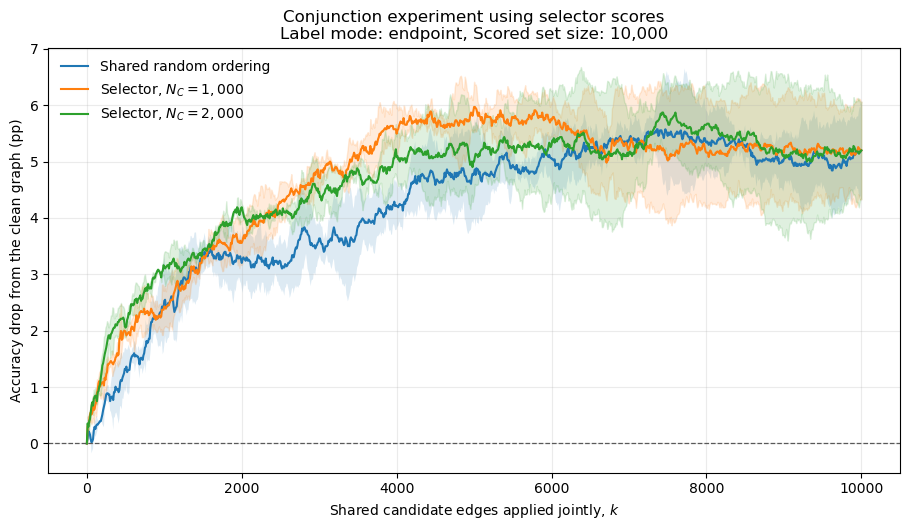

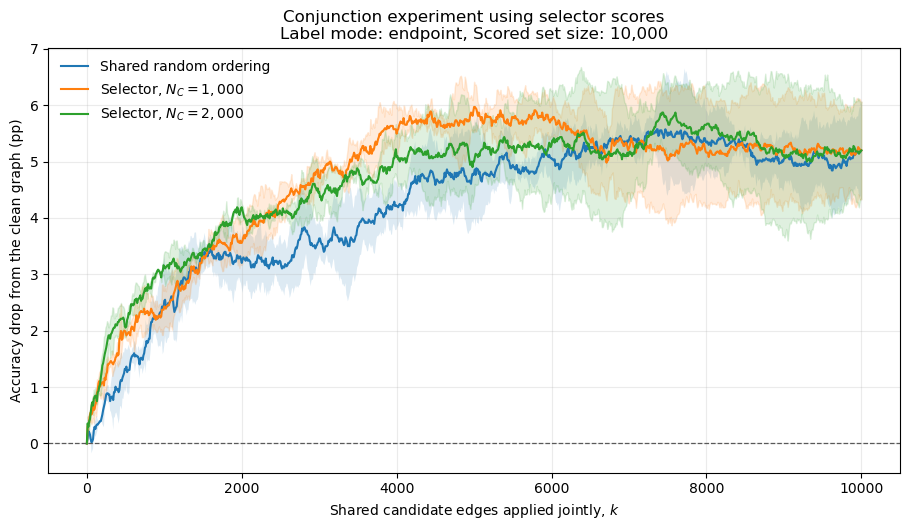

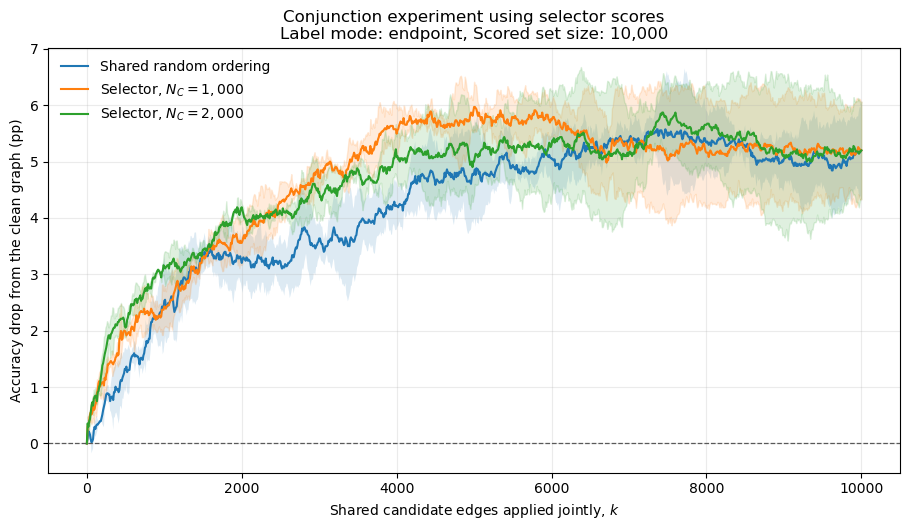

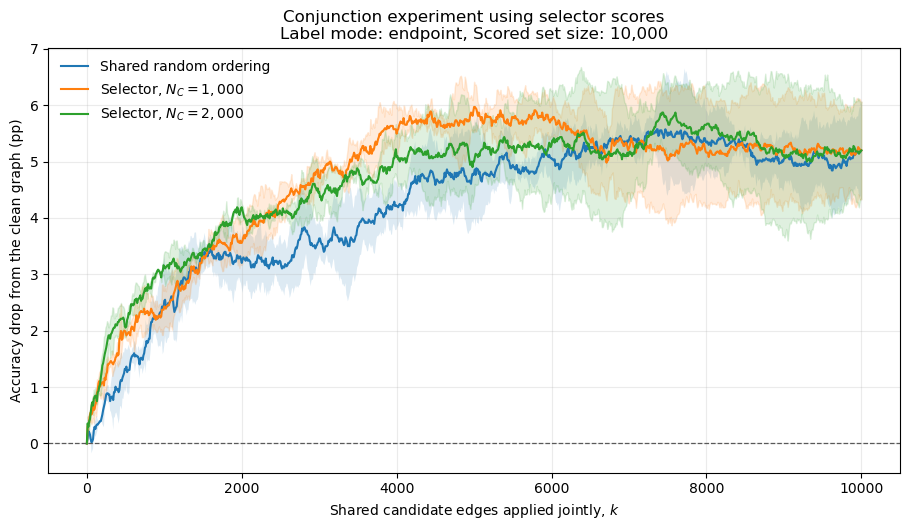

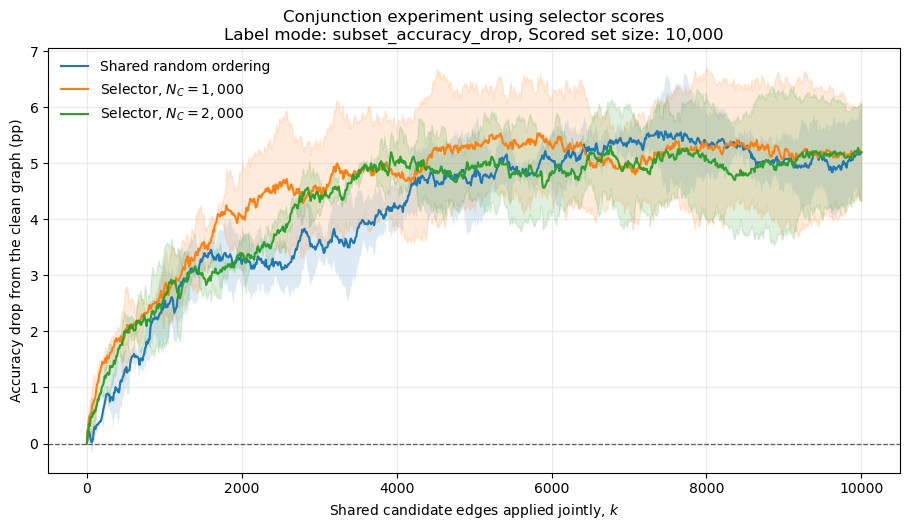

In [23]:
import matplotlib.pyplot as plt

SELECTOR_CONJUNCTION_PLOT_DIR = RQ3_SELECTOR_CONJUNCTION_OUT_DIR / "plots"
SELECTOR_CONJUNCTION_PLOT_DIR.mkdir(parents=True,exist_ok=True)

for label_mode in ["endpoint", "subset_accuracy_drop"]:

    # Separate endpoint and subset accuracy drop dataframes
    plot_df = rq3_selector_conjunction_results[rq3_selector_conjunction_results["label_mode"] == label_mode]
    fig, ax = plt.subplots(figsize=(9.2, 5.4))

    # Plot random ordering once as it is indipendent of training set size
    # Fix generated by ChatGPT 5.1
    random_df = (
        plot_df[plot_df["ordering"] == "random"]
        .sort_values(["candidate_set_size", "k"])
        .drop_duplicates("k")
        .rename(columns={
                "victim_accuracy_drop_mean": "mean",
                "victim_accuracy_drop_std": "std",
            }
        )
    )

    # Fill in random curve
    ax.plot(random_df["k"], 100*random_df["mean"],label="Shared random ordering")
    ax.fill_between(
        random_df["k"],
        100*random_df["mean"] - 100*random_df["std"],
        100*random_df["mean"] + 100*random_df["std"],
        alpha=0.15,
    )

    # Construct dataframe for selector orderings
    selector_ordering_df = plot_df[plot_df["ordering"] == "selector_score_desc"]
    training_sizes = sorted(selector_ordering_df["candidate_set_size"].unique())

    # Add curve for every candidate set size
    for candidate_set_size in training_sizes:
        selector_line = selector_ordering_df[selector_ordering_df["candidate_set_size"] == candidate_set_size].sort_values("k")

        line = ax.plot(
            selector_line["k"],
            100*selector_line["victim_accuracy_drop_mean"],
            label=f"Selector, "rf"$N_{{C}}={candidate_set_size:,}$",
        )[0]

        ax.fill_between(
            selector_line["k"],
            100*selector_line["victim_accuracy_drop_mean"]
            - 100*selector_line["victim_accuracy_drop_std"],
            100*selector_line["victim_accuracy_drop_mean"]
            + 100*selector_line["victim_accuracy_drop_std"],
            alpha=0.15,
            color=line.get_color(),
        )


    shared_cand_set_size = plot_df["shared_cand_set_size"].iloc[0]

    ax.axhline(0, linestyle="--", linewidth=0.9, color="0.35",)
    ax.set_xlabel(r"Shared candidate edges applied jointly, $k$")
    ax.set_ylabel("Accuracy drop from the clean graph (pp)")
    ax.set_title(
        "Conjunction experiment using selector scores\n"
        f"Label mode: {label_mode}, "
        f"Scored set size: {shared_cand_set_size:,}"
    )

    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

    fig.savefig(SELECTOR_CONJUNCTION_PLOT_DIR / f"rq3_selector_conjunction_{DATASET}_{label_mode}_new.png", dpi=200, bbox_inches="tight",)
    plt.show()

## 8. Model Guided PR-BCD

In [ ]:
# ============================================================
# RQ3: Selector-guided PRBCD sweep
# ============================================================

from itertools import product

PRBCD_BLOCK_SIZES = [5_000]
PRBCD_EPSILONS = [0.05]

PRBCD_USE_CERTS = [
    "none",
    "accuracy_drop_selector_with_resampling",
]

PRBCD_PARAMS = {
    "epochs": 150,
    "fine_tune_epochs": 100,
    "keep_heuristic": "WeightOnly",
    "do_synchronize": True,
    "loss_type": "tanhMargin",
}

PRBCD_SELECTOR_PARAMS = {
    "tau": 0.8,
    "score_batch_size": 1_000,
    "max_sampling_tries": 2_000_000,
    "exclude_tried": True,
    "top_k_per_batch": 100,
}

In [ ]:
# ============================================================
# RQ3: Run selector-guided PRBCD sweep
# ============================================================

from itertools import product
from timeit import default_timer as timer
from pathlib import Path

import gc
import traceback

import numpy as np
import pandas as pd
import torch

from DeleteCache import delete_pert_files_and_folders
from sparse_smoothing.utils import load_and_standardize


# ============================================================
# Configuration
# ============================================================

STOP_ON_ERROR = False

MODEL_STORAGE_TYPE = "demo_custom_split"

ARTIFACT_DIR = "cache"
PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"

RQ3_GUIDED_PRBCD_OUT_DIR = (RQ3_OUT_DIR / "rq3_guided_prbcd")
RQ3_GUIDED_PRBCD_OUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH = (
    RQ3_GUIDED_PRBCD_OUT_DIR
    / f"rq3_guided_prbcd_summary_{DATASET}.csv"
)

EPOCHS_PATH = (
    RQ3_GUIDED_PRBCD_OUT_DIR
    / f"rq3_guided_prbcd_epochs_{DATASET}.csv"
)

# ============================================================
# Load graph
# ============================================================

graph_sparse = load_and_standardize(
    f"data/{DATASET}.npz"
)

print(
    "Graph:",
    f"nodes={graph_sparse.attr_matrix.shape[0]}",
    f"features={graph_sparse.attr_matrix.shape[1]}",
    f"directed_edges={graph_sparse.adj_matrix.nnz}",
)


# ============================================================
# Run sweep
#
# mining_run
#   × block_size
#   × epsilon
#   × use_cert
# ============================================================

summary_rows = []
epoch_rows = []

total_runs = (
    len(mining_runs)
    * len(PRBCD_BLOCK_SIZES)
    * len(PRBCD_EPSILONS)
    * len(PRBCD_USE_CERTS)
)

sweep = product(
    mining_runs,
    PRBCD_BLOCK_SIZES,
    PRBCD_EPSILONS,
    PRBCD_USE_CERTS,
)


for run_index, (mining_run, block_size, epsilon, use_cert) in enumerate(sweep, start=1):

    seed = mining_run["seed"]
    candidate_set_size = mining_run["candidate_set_size"]
    scoring_mode = mining_run["scoring_mode"]
    selector_model = mining_run["selector_model"] if use_cert != "none" else None

    attack_params = {
        **PRBCD_PARAMS,
        "block_size": block_size,
        "lp_model": selector_model,
    }

    print("=" * 80)
    print(f"Run {run_index}/{total_runs}")
    print(
        f"seed={seed} | "
        f"candidate_set_size={candidate_set_size} | "
        f"scoring_mode={scoring_mode} | "
        f"block_size={block_size} | "
        f"epsilon={epsilon} | "
        f"use_cert={use_cert}"
    )

    delete_pert_files_and_folders(
        cache_dir=ARTIFACT_DIR,
        pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
        pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
    )

    # run prbcd
    start = timer()
    result = None
    try:
        result = experiment_global_attack_direct.run(
            graph=graph_sparse,
            data_dir="./data",
            dataset=DATASET,
            attack="PRBCD",
            attack_params=attack_params,
            selector_params=PRBCD_SELECTOR_PARAMS,
            epsilons=[epsilon],
            binary_attr=False,
            make_undirected=True,
            seed=seed,
            artifact_dir=ARTIFACT_DIR,
            pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
            pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
            model_label=MODEL_LABEL,
            model_storage_type=MODEL_STORAGE_TYPE,
            device="cpu",
            data_device="cpu",
            debug_level="info",
            semi=True,
            use_cert=use_cert,
        )

        elapsed = timer() - start
        final_accuracy = result["results"][0]["accuracy"]
        stats = result["attack_statistics"]

        summary_rows.append({
            "seed":seed,
            "candidate_set_size": candidate_set_size,
            "scoring_mode": scoring_mode,
            "block_size": block_size,
            "epsilon": epsilon,
            "use_cert": use_cert,
            "accuracy": final_accuracy,
            "runtime_seconds": elapsed,
            "status": "ok",
            "error":"",
        })

        for stat_idx in range(len(stats["accuracy"])):
            epoch_rows.append({
                "seed": seed,
                "candidate_set_size": candidate_set_size,
                "scoring_mode": scoring_mode,
                "block_size": block_size,
                "epsilon": epsilon,
                "use_cert": use_cert,
                "epoch": stat_idx - 1,
                "accuracy": stats["accuracy"][stat_idx],
                "loss": stats["loss"][stat_idx],
                "weights_above_eps": stats["weights_above_eps"][stat_idx],
                "probability_mass_update": stats["probability_mass_update"][stat_idx],
                "probability_mass_projected": stats["probability_mass_projected"][stat_idx],
            })

        print(f"Final accuracy: {final_accuracy:.6f}")
        print(f"Runtime: {elapsed:.2f} seconds")

    finally:
        del result
        gc.collect()

# ============================================================
# Raw dataframes
# ============================================================

rq3_guided_prbcd_summary = pd.DataFrame(summary_rows)
rq3_guided_prbcd_epochs = pd.DataFrame(epoch_rows)


# ============================================================
# Aggregate epoch trajectories across seeds
# ============================================================

rq3_guided_prbcd_results = (
    rq3_guided_prbcd_epochs
    .groupby([
            "candidate_set_size",
            "scoring_mode",
            "block_size",
            "epsilon",
            "use_cert",
            "epoch",
        ],
        as_index=False,
    )
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        loss_mean=("loss", "mean"),
        loss_std=("loss", "std"),
        weights_above_eps_mean=("weights_above_eps","mean"),
        weights_above_eps_std=("weights_above_eps","std"),
        probability_mass_update_mean=("probability_mass_update","mean"),
        probability_mass_update_std=("probability_mass_update","std"),
        probability_mass_projected_mean=("probability_mass_projected","mean"),
        probability_mass_projected_std=("probability_mass_projected","std"),
        n_seeds=("seed", "nunique"),
    )
)
# ============================================================
# Save
# ============================================================

RESULTS_PATH = (
    RQ3_GUIDED_PRBCD_OUT_DIR
    / f"rq3_guided_prbcd_results_{DATASET}.csv"
)

rq3_guided_prbcd_summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

rq3_guided_prbcd_epochs.to_csv(
    EPOCHS_PATH,
    index=False,
)

rq3_guided_prbcd_results.to_csv(
    RESULTS_PATH,
    index=False,
)

---
## §9  RQ1 — When Does PR-BCD Miss Harmful Edges?

This experiment constructs an **empirical high-budget PR-BCD reference** and compares ordinary PR-BCD runs across candidate block sizes.

The cell temporarily instruments PR-BCD at runtime and records:

- the initial candidate block;
- candidate blocks at every epoch;
- blocks immediately before and after resampling;
- accumulated positive gradients;
- maximum relaxed perturbation weights;
- final discrete perturbations;
- victim accuracy and runtime.

The optimization itself is unchanged. Reference and evaluation runs use separate PR-BCD sampling seeds so that small evaluation blocks are not trivial prefixes of the high-budget reference block.


In [ ]:
# ============================================================
# PRBCD block-size × resampling-duration experiment
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from DeleteCache import delete_pert_files_and_folders


EPSILON = 0.1
EPOCHS = 300

BLOCK_SIZES = [1_000, 5_000, 20_000, 50_000,]
N_RESAMPLING_EPOCHS_VALUES = [25, 50, 100, 150, 200]
rows = []
for seed in SEEDS:
    for block_size in BLOCK_SIZES:
        for n_resampling_epochs in N_RESAMPLING_EPOCHS_VALUES:
            fine_tune_epochs = (EPOCHS - n_resampling_epochs)
            print(
                f"seed={seed} | "
                f"block_size={block_size} | "
                f"resampling_epochs={n_resampling_epochs} | "
                f"fine_tune_epochs={fine_tune_epochs}"
            )
            # Drop old caches
            delete_pert_files_and_folders(
                cache_dir="cache",
                pert_adj_storage_type="evasion_global_adj",
                pert_attr_storage_type="evasion_global_attr",
            )
            attack_params = {
                "block_size": block_size,
                "epochs": EPOCHS,
                "fine_tune_epochs": fine_tune_epochs,
                "with_early_stopping": False,
                "keep_heuristic": "WeightOnly",
                "loss_type": "tanhMargin",
                "attack_sampling_seed": seed,
            }
            result = experiment_global_attack_direct.run(
                graph=graph_sparse,
                data_dir="./data",
                dataset=DATASET,
                attack="PRBCD",
                attack_params=attack_params,
                selector_params={},
                epsilons=[EPSILON],
                binary_attr=False,
                make_undirected=True,
                seed=seed,
                artifact_dir="cache",
                pert_adj_storage_type="evasion_global_adj",
                pert_attr_storage_type="evasion_global_attr",
                model_label=MODEL_LABEL,
                model_storage_type="demo_custom_split",
                device="cpu",
                data_device="cpu",
                debug_level="info",
                semi=True,
                use_cert="none",
            )
            final_accuracy = result["results"][0]["accuracy"]
            rows.append({
                "seed": seed,
                "block_size": block_size,
                "n_resampling_epochs": n_resampling_epochs,
                "fine_tune_epochs": fine_tune_epochs,
                "final_accuracy": float(final_accuracy),
            })

results = pd.DataFrame(rows)

summary = (
    results
    .groupby(
        [
            "block_size",
            "n_resampling_epochs",
            "fine_tune_epochs",
        ],
        as_index=False,
    )
    .agg(
        final_accuracy_mean=("final_accuracy", "mean"),
        final_accuracy_std=("final_accuracy", "std"),
        n_seeds=("seed", "nunique"),
    )
)


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

for block_size in BLOCK_SIZES:

    part = (
        summary[
            summary["block_size"] == block_size
        ]
        .sort_values("n_resampling_epochs")
    )

    ax.errorbar(
        part["n_resampling_epochs"],
        part["final_accuracy_mean"],
        yerr=part["final_accuracy_std"],
        marker="o",
        capsize=3,
        label=f"B = {block_size:,}",
    )

ax.set_xlabel("Number of resampling epochs")
ax.set_ylabel("Final attacked accuracy")

ax.set_title(
    "Final PRBCD accuracy by resampling duration\n"
    "Moving right gives PRBCD more resampling epochs"
)

ax.legend(title="Block size")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()